In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, FancyArrowPatch

We first generate the illustration for the exact one-sided circularised NUTS on the circle orbit.

1. Continuous case (when the tuning parameter distribution is continuous uniform, for exact flow).

2. Discrete case (when the tuning parameter distribution is discrete uniform, for leapfrog flow).

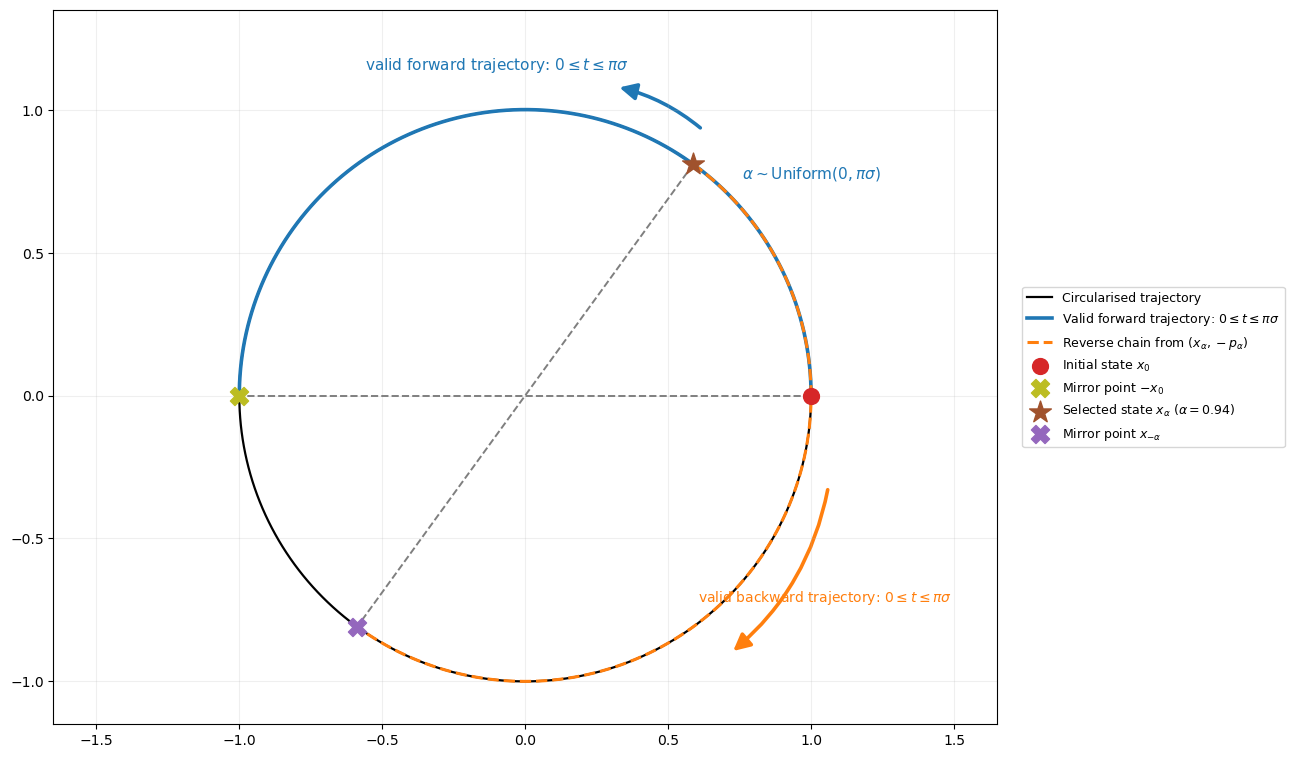

In [2]:
# ============================================================
# Continuous-time exact Hamiltonian flow for a 2D isotropic
# Gaussian target illustration
# ============================================================

# ============================================================
# Parameters
# ============================================================
sigma = 1.0
radius = 1.0

# Choose one realised continuous time alpha in (0, pi*sigma)
alpha_fraction = 0.30
alpha = alpha_fraction * np.pi * sigma
theta_alpha = alpha / sigma

# ============================================================
# Key points
# ============================================================
x0 = np.array([radius, 0.0])
mirror_x0 = np.array([-radius, 0.0])

x_alpha = np.array([
    radius * np.cos(theta_alpha),
    radius * np.sin(theta_alpha),
])

# Mirror point of x_alpha
x_mirror_alpha = -x_alpha

# ============================================================
# Continuous trajectories
# ============================================================
theta = np.linspace(0, 2 * np.pi, 1000)

# Valid forward trajectory: from x0 to -x0
theta_forward = np.linspace(0.0, np.pi, 500)
xf = radius * np.cos(theta_forward)
yf = radius * np.sin(theta_forward)

# Valid backward trajectory:
# after selecting x_alpha and reversing momentum,
# the motion is clockwise from x_alpha to x_{-alpha}
theta_backward = np.linspace(theta_alpha, theta_alpha - np.pi, 500)
xb = radius * np.cos(theta_backward)
yb = radius * np.sin(theta_backward)

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Full circular trajectory
circle_line, = ax.plot(
    radius * np.cos(theta),
    radius * np.sin(theta),
    linewidth=1.6,
    color="black",
    label="Circularised trajectory",
)

# ============================================================
# Forward trajectory
# ============================================================
forward_line, = ax.plot(
    xf,
    yf,
    linewidth=2.6,
    color="tab:blue",
    label=r"Valid forward trajectory: $0 \leq t \leq \pi\sigma$",
)

# ============================================================
# Backward trajectory
# ============================================================
reverse_line, = ax.plot(
    xb,
    yb,
    linestyle="--",
    linewidth=2.2,
    color="tab:orange",
    label=r"Reverse chain from $(x_\alpha,-p_\alpha)$",
)

# ============================================================
# Mirror / connecting lines
# ============================================================
mirror_x0_line, = ax.plot(
    [x0[0], mirror_x0[0]],
    [x0[1], mirror_x0[1]],
    linestyle="--",
    linewidth=1.4,
    color="tab:gray",
    # label=r"Mirror line through $x_0$ and $-x_0$",
)

mirror_alpha_line, = ax.plot(
    [x_alpha[0], x_mirror_alpha[0]],
    [x_alpha[1], x_mirror_alpha[1]],
    linestyle="--",
    linewidth=1.4,
    color="tab:gray",
    # label=r"Line from $x_\alpha$ to mirror point $x_{-\alpha}$",
)

# ============================================================
# Special states
# ============================================================
x0_pt = ax.scatter(
    [x0[0]],
    [x0[1]],
    s=130,
    color="tab:red",
    zorder=8,
    label=r"Initial state $x_0$",
)

mirror_x0_pt = ax.scatter(
    [mirror_x0[0]],
    [mirror_x0[1]],
    s=170,
    marker="X",
    color="tab:olive",
    zorder=8,
    label=r"Mirror point $-x_0$",
)

xalpha_pt = ax.scatter(
    [x_alpha[0]],
    [x_alpha[1]],
    s=270,
    marker="*",
    color="sienna",
    zorder=9,
    label=rf"Selected state $x_\alpha$ ($\alpha={alpha:.2f}$)",
)

mirror_alpha_pt = ax.scatter(
    [x_mirror_alpha[0]],
    [x_mirror_alpha[1]],
    s=170,
    marker="X",
    color="tab:purple",
    zorder=8,
    label=r"Mirror point $x_{-\alpha}$",
)

# ============================================================
# Small text labels
# ============================================================
ax.text(
    -0.10, 1.14,
    r"valid forward trajectory: $0 \leq t \leq \pi\sigma$",
    fontsize=11,
    ha="center",
    color="tab:blue",
)

ax.text(
    1.05, -0.72,
    r"valid backward trajectory: $0 \leq t \leq \pi\sigma$",
    fontsize=10,
    color="tab:orange",
    ha="center"
)

# Optional small note for alpha
ax.annotate(
    r"$\alpha \sim \mathrm{Uniform}(0,\pi\sigma)$",
    xy=x_alpha,
    xytext=(35, -10),
    textcoords="offset points",
    fontsize=11,
    color="tab:blue"
)

# ============================================================
# Direction arrows
# ============================================================
forward_arrow = FancyArrowPatch(
    (0.62, 0.93),
    (0.32, 1.08),
    connectionstyle="arc3,rad=0.12",
    arrowstyle="-|>",
    mutation_scale=25,
    linewidth=2.6,
    color="tab:blue",
)
ax.add_patch(forward_arrow)

reverse_arrow = FancyArrowPatch(
    (1.06, -0.32),
    (0.72, -0.90),
    connectionstyle="arc3,rad=-0.18",
    arrowstyle="-|>",
    mutation_scale=25,
    linewidth=2.6,
    color="tab:orange",
)
ax.add_patch(reverse_arrow)

# ============================================================
# Axes / formatting
# ============================================================
ax.set_aspect("equal")
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(-1.15, 1.35)

ax.grid(alpha=0.2)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

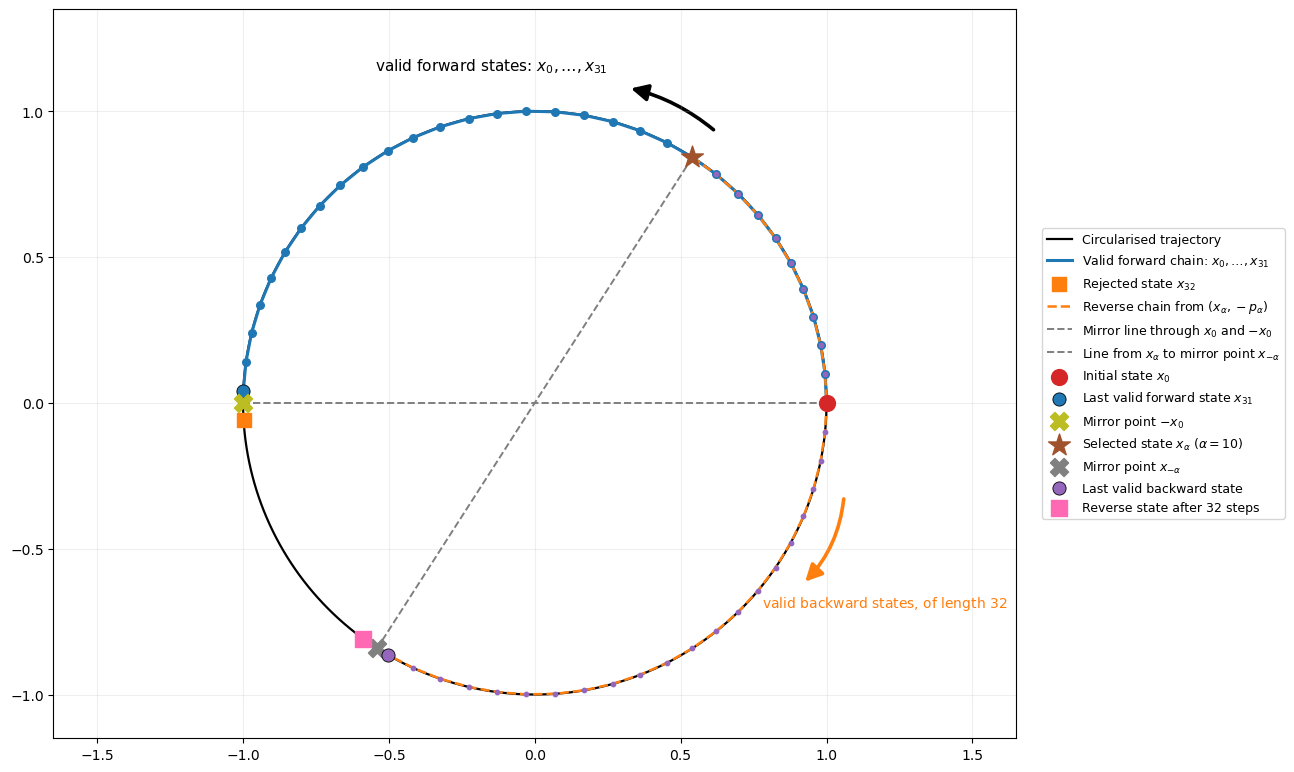

In [3]:
# Discrete-time exact Hamiltonian flow for a 2D isotropic Gaussian target illustration

# ============================================================
# Parameters
# ============================================================
epsilon = 0.1
sigma = 1.0
radius = 1.0

tau = int(np.ceil(np.pi * sigma / epsilon))   # tau = 32
k_star = tau - 1                              # k_star = 31
alpha = 10

# ============================================================
# Forward trajectory
# ============================================================
forward_indices = np.arange(tau + 1)
forward_angles = forward_indices * epsilon / sigma

xf = radius * np.cos(forward_angles)
yf = radius * np.sin(forward_angles)

# ============================================================
# Selected state x_alpha and its mirror point
# ============================================================
theta_alpha = alpha * epsilon / sigma

x_alpha = np.array([
    radius * np.cos(theta_alpha),
    radius * np.sin(theta_alpha),
])

theta_mirror_alpha = theta_alpha + np.pi
x_mirror_alpha = np.array([
    radius * np.cos(theta_mirror_alpha),
    radius * np.sin(theta_mirror_alpha),
])

# ============================================================
# Reverse chain from (x_alpha, -p_alpha)
# ============================================================
reverse_indices = np.arange(tau + 1)
reverse_angles = theta_alpha - reverse_indices * epsilon / sigma

xr = radius * np.cos(reverse_angles)
yr = radius * np.sin(reverse_angles)

# Reverse state after 32 reverse steps
x_reverse_32 = np.array([xr[tau], yr[tau]])

# Mirror point of x0
mirror_x0 = np.array([-radius, 0.0])

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Full circular trajectory
theta = np.linspace(0, 2 * np.pi, 1000)
circle_line, = ax.plot(
    radius * np.cos(theta),
    radius * np.sin(theta),
    linewidth=1.6,
    color="black",
    label="Circularised trajectory",
)

# ============================================================
# Forward chain
# ============================================================
forward_line, = ax.plot(
    xf[:k_star + 1],
    yf[:k_star + 1],
    linewidth=2.2,
    color="tab:blue",
    label=r"Valid forward chain: $x_0,\ldots,x_{31}$",
)

ax.scatter(
    xf[:k_star + 1],
    yf[:k_star + 1],
    s=30,
    color="tab:blue",
    zorder=3,
)

# Rejected state x32 -> square
rejected_pt = ax.scatter(
    [xf[tau]],
    [yf[tau]],
    marker="s",
    s=110,
    color="tab:orange",
    zorder=8,
    label=r"Rejected state $x_{32}$",
)

# ============================================================
# Reverse chain
# ============================================================
reverse_line, = ax.plot(
    xr[:tau + 1],
    yr[:tau + 1],
    linestyle="--",
    linewidth=1.8,
    color="tab:orange",
    label=r"Reverse chain from $(x_\alpha,-p_\alpha)$",
)

ax.scatter(
    xr[:k_star + 1],
    yr[:k_star + 1],
    s=10,
    color="tab:purple",
    zorder=4,
)

# ============================================================
# Mirror / connecting lines
# ============================================================
# Diameter from x0 to -x0
mirror_x0_line, = ax.plot(
    [xf[0], mirror_x0[0]],
    [yf[0], mirror_x0[1]],
    linestyle="--",
    linewidth=1.4,
    color="tab:gray",
    label=r"Mirror line through $x_0$ and $-x_0$",
)

# Red dashed line from x_alpha to mirror point x_{-\alpha}
mirror_alpha_line, = ax.plot(
    [x_alpha[0], x_mirror_alpha[0]],
    [x_alpha[1], x_mirror_alpha[1]],
    linestyle="--",
    linewidth=1.4,
    color="tab:gray",
    label=r"Line from $x_\alpha$ to mirror point $x_{-\alpha}$",
)

# ============================================================
# Special states
# ============================================================
x0_pt = ax.scatter(
    [xf[0]],
    [yf[0]],
    s=130,
    color="tab:red",
    zorder=8,
    label=r"Initial state $x_0$",
)

x31_pt = ax.scatter(
    [xf[k_star]],
    [yf[k_star]],
    s=90,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.6,
    zorder=8,
    label=r"Last valid forward state $x_{31}$",
)

# mirror point of x0 -> cross
mirror_x0_pt = ax.scatter(
    [mirror_x0[0]],
    [mirror_x0[1]],
    s=170,
    marker="X",
    color="tab:olive",
    zorder=8,
    label=r"Mirror point $-x_0$",
)

xalpha_pt = ax.scatter(
    [x_alpha[0]],
    [x_alpha[1]],
    s=270,
    marker="*",
    color="sienna",
    zorder=9,
    label=rf"Selected state $x_\alpha$ ($\alpha={alpha}$)",
)

mirror_alpha_pt = ax.scatter(
    [x_mirror_alpha[0]],
    [x_mirror_alpha[1]],
    s=170,
    marker="X",
    color="gray",
    zorder=8,
    label=r"Mirror point $x_{-\alpha}$",
)

reverse31_pt = ax.scatter(
    [xr[k_star]],
    [yr[k_star]],
    s=90,
    color="tab:purple",
    edgecolor="black",
    linewidth=0.6,
    zorder=8,
    label=r"Last valid backward state",
)

reverse32_pt = ax.scatter(
    [x_reverse_32[0]],
    [x_reverse_32[1]],
    s=125,
    marker="s",
    color="hotpink",
    zorder=9,
    label=r"Reverse state after 32 steps",
)

# ============================================================
# Small text label kept on top
# ============================================================
ax.text(
    -0.15, 1.14,
    r"valid forward states: $x_0,\ldots,x_{31}$",
    fontsize=11,
    ha="center"
)

# ============================================================
# Direction arrows
# ============================================================
forward_arrow = FancyArrowPatch(
    (0.62, 0.93),
    (0.32, 1.08),
    connectionstyle="arc3,rad=0.12",
    arrowstyle="-|>",
    mutation_scale=25,
    linewidth=2.6,
    color="black",
)
ax.add_patch(forward_arrow)

reverse_arrow = FancyArrowPatch(
    (1.06, -0.32),
    (0.92, -0.62),
    connectionstyle="arc3,rad=-0.18",
    arrowstyle="-|>",
    mutation_scale=25,
    linewidth=2.6,
    color="tab:orange",
)
ax.add_patch(reverse_arrow)

ax.text(
    1.2, -0.7,
    r"valid backward states, of length $32$",
    fontsize=10,
    color="tab:orange",
    ha="center"
)

# ============================================================
# Axes / formatting
# ============================================================
ax.set_aspect("equal")
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(-1.15, 1.35)

# ax.set_title(
#     "One-sided circularised NUTS / GIST on a discrete grid of the exact Hamiltonian flow",
#     fontsize=14,
# )

ax.grid(alpha=0.2)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

Then we sample and check that the exact one-sided circularised NUTS DOES improve the mixing.

## Exact one-sided NUTS as a GIST sampler

### Note for function <code>_distance_score_angle</code>
This function evaluates the ordinary distance-based U-turn score $g(t)=(x_t-x_0)^T p_t$ for an isotropic Gaussian target. The stopping time is the first positive time at which
$g(t)\le 0$. It is written in terms of the scalar angle $\theta=\frac{t}{\sigma}$ and the three centered quantities:

$$
A=|x_0-\mu|^2,\qquad
B=(x_0-\mu)^T p_0,\qquad
C=|p_0|^2
$$

#### 1. Exact isotropic Gaussian flow

Let $q_0=x_0-\mu$. For the target $x\sim \mathcal N(\mu,\sigma^2I_d)$ with identity mass matrix, the exact Hamiltonian flow is

$$
\begin{aligned}
q_t &= \cos(\theta)q_0 + \sigma\sin(\theta)p_0\\
p_t &= \cos(\theta)p_0 - \frac{\sin(\theta)}{\sigma}q_0
\end{aligned}
$$
where $\theta=t/\sigma$. Because $x_t=\mu+q_t$, then $x_t-x_0=q_t-q_0$. Therefore, $x_t-x_0 = \bigl(\cos\theta-1\bigr)q_0 + \sigma\sin\theta p_0$. 

For brevity, write $c=\cos\theta$ and $s=\sin\theta$, then 

$$
\begin{aligned}
x_t-x_0 &= (c-1)q_0+\sigma s p_0\\
p_t &= cp_0-\frac{s}{\sigma}q_0.
\end{aligned}
$$


#### 2. Expand the U-turn score
Now take their inner product:

$$
\begin{aligned}
(x_t-x_0)^T p_t &= \left[(c-1)q_0+\sigma s p_0\right]^T \left[cp_0-\frac{s}{\sigma}q_0\right]\\
&= c(c-1)q_0^T p_0 -\frac{s(c-1)}{\sigma}q_0^T q_0 +\sigma sc p_0^T p_0 -s^2p_0^T q_0\\
&= \left[c(c-1)-s^2\right]B -\frac{s(c-1)}{\sigma}A +\sigma sc C\\
&= \left(\cos(2\theta)-\cos\theta\right)B + \frac{\sin\theta(1-\cos\theta)}{\sigma}A +\sigma\sin\theta\cos\theta C
\end{aligned}
$$
by letting $A=q_0^T q_0$, $B=q_0^T p_0$ and $C=p_0^T p_0$ respectively, which matches the code:

```python
return float(
    (np.cos(2.0 * theta) - cosine) * B
    + sine * (1.0 - cosine) * A / self.sigma
    + self.sigma * sine * cosine * C
)
```


### Note for function <code>stopping_time</code>

From <code>_distance_score_angle</code> we already see the distance-based stopping condition is summarised as
$$
\begin{aligned}
g(\theta) = \left(\cos(2\theta)-\cos\theta\right)B + \frac{\sin\theta(1-\cos\theta)}{\sigma}A +\sigma\sin\theta\cos\theta C
\end{aligned}
$$

Now, under the half-angle setting, $z=\tan\left(\frac{\theta}{2}\right)$, we have $\sin\theta=\frac{2z}{1+z^2}$ and $\cos\theta=\frac{1-z^2}{1+z^2}$. Together with trigonometry properties, we can rewrite $g(\theta)$ in terms of

$$
g(\theta) = \frac{2z}{(1+z^2)^2}\left[Bz(z^2-3) + \frac{2A}{\sigma}z^2 + \sigma C(1-z^2)\right]
$$

In order to solve $g(\theta) = 0$, obviously we have two possible cases that

1. Trivial root: $\frac{2z}{(1+z^2)^2} = 0 \implies z=0 \iff \theta = 0 \iff t=0$, but the stopping time is defined using the first positive root, so we shall reject the trivial root.

2. Solve the cubic equation $Bz(z^2-3) + \frac{2A}{\sigma}z^2 + \sigma C(1-z^2)$, which is equivalent to solve
    $$
    B\sigma z^3 + (2A-C\sigma^2)z^2 - 3B\sigma z + C\sigma^2 =0
    $$
    which matches the main idea in <code>stopping_time</code>.

Once a real root $z$ is found, recover the corresponding angle using $\theta=2\arctan(z)$. Because `np.arctan` returns values in $(-\pi/2,\pi/2)$, the resulting $2\arctan(z)$ lies in $(-\pi,\pi)$. **The stopping time $\tau(x_0, p_0)$ must be positive based on definition**, so for a negative result, the code adds $2\pi$ to obtain the corresponding positive angle:

```python
theta = 2.0 * np.arctan(z)

if theta <= root_tolerance:
    theta += 2.0 * np.pi
```

Then $t=\sigma\theta$ is the smallest admissible positive value gives the first U-turn time.

Lastly, Therefore, $\theta=\pi$ must be checked separately as it results $z=\tan(\theta/2)\to \infty$. From the original score, $g(\pi) = \bigl(\cos(2\pi)-\cos\pi\bigr)B = 2B$, meaning that $\theta=\pi$ is a root exactly when $B=0$. We need to check this case separately and shown in the code <code>stopping_time</code>. The full logic is:

$$
\begin{aligned}
g(\theta)=0
&\Longrightarrow z=0
&&\text{(the trivial root }\theta=0\text{)},\\
&\quad\text{or the cubic equation holds},
&&\text{for finite }z,\\
&\quad\text{or }\theta=\pi\text{ is checked separately},
&&\text{because }z=\infty.
\end{aligned}
$$


In [4]:
from __future__ import annotations

from typing import Optional

class ordinary_GIST_NUTS_continuous_isotropic:
    """
    Continuous-time, one-sided exact-flow GIST sampler for

        x ~ N(mean, sigma^2 I_d),
        p ~ N(0, I_d).

    The default stopping rule is the ordinary distance-based rule

        tau(x, p)
          = inf{t > 0 : (x_t - x)^T p_t <= 0}.

    A continuous integration time is sampled as

        alpha ~ Uniform(0, tau_1),

    and the proposal is

        (x_proposed, p_proposed)
          = S o phi_alpha(x, p)
          = (x_alpha, -p_alpha).

    The exact-flow GIST acceptance probability is

        min(1, tau_1 / tau_2) 1{tau_2 >= alpha}.
    """

    def __init__(
        self,
        dimension: int,
        sigma: float = 1.0,
        mean: Optional[np.ndarray] = None,
        uturn_condition: str = "distance",
        root_tolerance: float = 1e-10,
        seed: Optional[int] = None,
    ) -> None:

        if not isinstance(dimension, (int, np.integer)) or dimension < 1:
            raise ValueError("dimension must be a positive integer.")

        if not np.isfinite(sigma) or sigma <= 0:
            raise ValueError("sigma must be positive and finite.")

        if uturn_condition not in {"distance", "angle"}:
            raise ValueError(
                "uturn_condition must be 'distance' or 'angle'."
            )

        if root_tolerance <= 0:
            raise ValueError("root_tolerance must be positive.")

        self.dimension = int(dimension)
        self.sigma = float(sigma)
        self.uturn_condition = uturn_condition
        self.root_tolerance = float(root_tolerance)

        if mean is None:
            self.mean = np.zeros(self.dimension)  # set default zero mean
        else:
            self.mean = np.asarray(mean, dtype=float)

            if self.mean.shape != (self.dimension,):
                raise ValueError(
                    f"mean must have shape ({self.dimension},)."
                )

            if not np.all(np.isfinite(self.mean)):
                raise ValueError("mean contains non-finite values.")

        self.rng = np.random.default_rng(seed)

    # ========================================================
    # Validation
    # ========================================================

    def _validate_vector(
        self,
        value: np.ndarray,
        name: str,
    ) -> np.ndarray:

        value = np.asarray(value, dtype=float)

        if value.shape != (self.dimension,):
            raise ValueError(
                f"{name} must have shape ({self.dimension},)."
            )

        if not np.all(np.isfinite(value)):
            raise ValueError(
                f"{name} contains non-finite values."
            )

        return value

    # ========================================================
    # Exact isotropic Gaussian Hamiltonian flow
    # ========================================================

    def exact_flow(
        self,
        x: np.ndarray,
        p: np.ndarray,
        time: float,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Evaluate the exact flow at any real-valued time.

        For q = x - mean and theta = time / sigma,

            q_t = cos(theta) q + sigma sin(theta) p,

            p_t = cos(theta) p - sin(theta) q / sigma.
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        time = float(time)

        if not np.isfinite(time):
            raise ValueError("time must be finite.")

        theta = time / self.sigma
        cosine = np.cos(theta)
        sine = np.sin(theta)

        q_initial = x - self.mean  # centered position

        x_time = (
            self.mean
            + cosine * q_initial
            + self.sigma * sine * p
        )  # x_t, the position at time t, shifting with the mean

        p_time = (
            cosine * p
            - (sine / self.sigma) * q_initial
        )  # p_t, the momentum at time t

        return x_time, p_time

    # ========================================================
    # Hamiltonian energy
    # ========================================================

    def hamiltonian(
        self,
        x: np.ndarray,
        p: np.ndarray,
    ) -> float:
        """
        Compute Hamiltonian (energy)

            H(x,p)
              = ||x-mean||^2 / (2 sigma^2)
                + ||p||^2 / 2.
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        q = x - self.mean

        potential = (
            np.dot(q, q)
            / (2.0 * self.sigma**2)
        )

        kinetic = 0.5 * np.dot(p, p)

        return float(potential + kinetic)

    # ========================================================
    # Distance-based U-turn score
    # ========================================================

    def uturn_score(
        self,
        theta: float,
        A: float,
        B: float,
        C: float,
    ) -> float:
        """
        Return

            (x_t-x_0)^T p_t

        as a function of theta = t / sigma, where centered form are used:

            A = ||x_0-mean||^2,
            B = (x_0-mean)^T p_0,
            C = ||p_0||^2.
        """
        cosine = np.cos(theta)
        sine = np.sin(theta)

        return float(
            (np.cos(2.0 * theta) - cosine) * B
            + sine * (1.0 - cosine) * A / self.sigma
            + self.sigma * sine * cosine * C
        )

    # ========================================================
    # Continuous stopping time
    # ========================================================

    def stopping_time(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> float:
        """
        Return the first positive continuous U-turn time.
        """
        x_initial = self._validate_vector(
            x_initial,
            "x_initial",
        )

        p_initial = self._validate_vector(
            p_initial,
            "p_initial",
        )

        q_initial = x_initial - self.mean

        # Define correct A, B, C for the centered form of the distance-based U-turn score
        A = float(np.dot(q_initial, q_initial))
        B = float(np.dot(q_initial, p_initial))
        C = float(np.dot(p_initial, p_initial))

        if C <= self.root_tolerance:
            raise ValueError(
                "The supplied momentum is numerically zero."
            )

        # ----------------------------------------------------
        # Angle-based condition:
        #
        # p_0^T p_t
        #   = C cos(theta) - (B/sigma) sin(theta).
        #
        # Its first positive root is explicit.
        # ----------------------------------------------------
        if self.uturn_condition == "angle":
            theta_star = np.arctan2(
                self.sigma * C,
                B,
            )

            return float(
                self.sigma * theta_star
            )

        # ----------------------------------------------------
        # Distance-based condition.
        #
        # With z = tan(theta/2), nonzero roots satisfy
        #
        # B sigma z^3
        # + (2A-C sigma^2) z^2
        # - 3B sigma z
        # + C sigma^2 = 0.
        # ----------------------------------------------------
        coefficients = np.array(
            [
                B * self.sigma,
                2.0 * A - C * self.sigma**2,
                -3.0 * B * self.sigma,
                C * self.sigma**2,
            ],
            dtype=float,
        )  # coefficients of the cubic polynomial in z = tan(theta/2)

        coefficient_scale = max(
            1.0,
            float(np.max(np.abs(coefficients))),
        )  # Give a reference scale for deciding whether a coefficient is numerically negligible.

        coefficients[
            np.abs(coefficients)
            <= self.root_tolerance * coefficient_scale
        ] = 0.0  # Set numerically negligible coefficients to zero.

        # Remove leading zero coefficients when the cubic degenerates to a quadratic or linear polynomial.
        # Record the indices of nonzero coefficients to slice the array.
        # For example, if the polynomial is quadratic, then coefficients = [0, a, b, c] and nonzero_indices = [1, 2, 3].
        nonzero_indices = np.flatnonzero(coefficients)

        if nonzero_indices.size == 0:
            raise RuntimeError(
                "Degenerate stopping-time polynomial."
            )

        # Slice the array to remove leading zeros, so that the first coefficient is nonzero.
        # With the above example, coefficients now becomes [a, b, c] by removing leading zeros.
        coefficients = coefficients[
            nonzero_indices[0]:
        ]

        roots = np.roots(coefficients)  # return the roots (z) for the polynomial with the given coefficients.

        # The trajectory is periodic with period 2*pi*sigma.
        # The full period is always a fallback zero.
        candidate_angles = [2.0 * np.pi]

        # theta = pi is omitted by z = tan(theta/2).
        # It is a root precisely when B = q_0^T p_0 = 0.
        orthogonality_scale = max(
            1.0,
            np.sqrt(A * C),  # Cauchy-Schwarz inequality: |B| <= sqrt(A*C)
        )

        if abs(B) <= (
            self.root_tolerance
            * orthogonality_scale
        ):
            candidate_angles.append(np.pi)

        residual_scale = max(
            1.0,
            A / self.sigma
            + abs(B)
            + self.sigma * C,
        )

        for root in roots:
            # Retain numerically real roots.
            if abs(root.imag) > (
                1e-8
                * max(1.0, abs(root.real))
            ):
                continue

            z = float(root.real)

            theta = 2.0 * np.arctan(z)

            # arctan returns theta in (-pi, pi).
            # Convert negative angles to (pi, 2*pi).
            if theta <= self.root_tolerance:
                theta += 2.0 * np.pi

            if not (
                self.root_tolerance
                < theta
                <= 2.0 * np.pi
                + self.root_tolerance
            ):
                continue

            residual = self.uturn_score(
                theta, A, B, C,
            )
            

            if abs(residual) <= (
                1e-7 * residual_scale
            ):
                candidate_angles.append(
                    min(theta, 2.0 * np.pi)
                )

        theta_star = min(candidate_angles)

        return float(
            self.sigma * theta_star
        )

    # ========================================================
    # One exact-flow GIST transition
    # ========================================================

    def transition(
        self,
        x_current: np.ndarray,
    ) -> tuple[np.ndarray, dict]:
        """
        Perform one continuous-time exact-flow GIST transition.
        """
        x_current = self._validate_vector(
            x_current,
            "x_current",
        )

        # Refresh the momentum.
        p_initial = self.rng.normal(
            size=self.dimension
        )

        # Forward stopping time.
        tau_1 = self.stopping_time(
            x_current,
            p_initial,
        )

        # Continuous Gibbs update of integration time.
        alpha = self.rng.uniform(
            0.0,
            tau_1,
        )

        # Exact-flow state at time alpha.
        x_alpha, p_alpha = self.exact_flow(
            x_current,
            p_initial,
            alpha,
        )

        # Momentum reversal.
        x_proposed = x_alpha.copy()
        p_proposed = -p_alpha

        # Reverse stopping time.
        tau_2 = self.stopping_time(
            x_proposed,
            p_proposed,
        )

        # Exact-flow GIST acceptance probability.
        if tau_2 + self.root_tolerance < alpha:
            acceptance_probability = 0.0
        else:
            acceptance_probability = min(
                1.0,
                tau_1 / tau_2,
            )

        # Accept the transition under Metropolis-Hastings criterion:
        # generate a uniform random number in [0,1) and accept if it is less than the acceptance probability.
        accepted = bool(
            self.rng.uniform()
            < acceptance_probability
        )
        if accepted:
            x_next = x_proposed
        else:
            x_next = x_current.copy()

        initial_energy = self.hamiltonian(
            x_current,
            p_initial,
        )

        proposed_energy = self.hamiltonian(
            x_alpha,
            p_alpha,
        )

        information = {
            "accepted": accepted,  # bool value
            "acceptance_probability": (
                acceptance_probability
            ),
            "momentum": p_initial.copy(),
            "proposal": x_proposed.copy(),
            "proposal_momentum": p_proposed.copy(),
            "tau_1": tau_1,
            "tau_2": tau_2,
            "alpha": alpha,
            "energy_error": float(
                proposed_energy - initial_energy
            ),  # should be zero (or very small value due to numerical errors) for exact flow, but we record it for diagnostics
        }

        return x_next, information

    # ========================================================
    # Generate the Markov chain
    # ========================================================

    def sample(
        self,
        initial_position: np.ndarray,
        n_samples: int,
        burn_in: int = 0,
        thin: int = 1,
    ) -> tuple[np.ndarray, dict]:

        if n_samples < 1:
            raise ValueError(
                "n_samples must be positive."
            )

        if burn_in < 0:
            raise ValueError(
                "burn_in must be nonnegative."
            )

        # Thinning factor controls how frequently the Markov-chain states are retained after burn-in, 
        # thin=1 means retain every state, thin=2 means retain every second state, etc.
        if thin < 1:
            raise ValueError(
                "thin must be positive."
            )

        current = self._validate_vector(
            initial_position,
            "initial_position",
        ).copy()  # initialise

        total_transitions = (
            burn_in + n_samples * thin
        )

        samples = np.empty(
            (n_samples, self.dimension)
        )  # initialise array to store the samples

        # Initialise array to store acceptance indicators,
        # bool values indicating whether each transition was accepted or rejected, see 'transition'
        accepted = np.empty(total_transitions, dtype=bool)

        acceptance_probabilities = np.empty(total_transitions)  # initialise array to store acceptance probabilities

        # Initialise arrays to store tau_1, tau_2, alpha, and energy errors for diagnostics
        tau_1_values = np.empty(total_transitions)
        tau_2_values = np.empty(total_transitions)
        alpha_values = np.empty(total_transitions)  # tuning parameter alpha
        energy_errors = np.empty(total_transitions)

        sample_index = 0  # initialise from zero index (x0, p0)

        for iteration in range(total_transitions):
            # Store and update information for each iteration
            current, information = self.transition(
                current
            )

            accepted[iteration] = information["accepted"]
            acceptance_probabilities[iteration] = information["acceptance_probability"]
            tau_1_values[iteration] = information["tau_1"]
            tau_2_values[iteration] = information["tau_2"]
            alpha_values[iteration] = information["alpha"]  # chosen tuning parameter at this iteration
            energy_errors[iteration] = information["energy_error"]

            # Record warm-up samples after burn-in and thinning
            if iteration >= burn_in:
                post_burn_iteration = (
                    iteration - burn_in
                )

                if post_burn_iteration % thin == 0:
                    samples[sample_index] = current
                    sample_index += 1  # update sample index for the next retained sample

        # Return the samples and diagnostics information for the whole chain, as a dictionary for further analysis
        diagnostics = {
            "accepted": accepted,
            "acceptance_probability": (
                acceptance_probabilities
            ),
            "tau_1": tau_1_values,
            "tau_2": tau_2_values,
            "alpha": alpha_values,
            "energy_error": energy_errors,
            "acceptance_rate": float(
                np.mean(accepted)  # average acceptance rate over the whole chain
            ),
            "mean_acceptance_probability": float(
                np.mean(
                    acceptance_probabilities
                )
            ),
        }

        return samples, diagnostics

In [5]:
sampler = ordinary_GIST_NUTS_continuous_isotropic(
    dimension=2,
    sigma=1.0,
    mean=np.zeros(2),
    uturn_condition="distance",
    seed=0,
)

# Run the sampler to generate a full chain of samples from the target distribution
samples, diagnostics = sampler.sample(
    initial_position=np.array([2.0, 3.0]),
    n_samples=1000,
    burn_in=0,  # we consider the cold-start scenario, so no burn-in is applied
)

print("Acceptance rate:", diagnostics["acceptance_rate"])

Acceptance rate: 0.655


1-step samples check.

In [6]:
n_iter = 1000
dimension = 2
one_step_samples = np.empty((n_iter, 2))
initial_position = np.array([2.0, 3.0])  # starting point for the Markov chain
rejected_move = 0  # counter for rejected moves

sampler = ordinary_GIST_NUTS_continuous_isotropic(
    dimension=dimension,
    sigma=1.0,
    mean=np.zeros(dimension),
    uturn_condition="distance",
    seed=0,
)

for i in range(n_iter):
    samples, diagnostics = sampler.sample(
        initial_position=initial_position,
        n_samples=1,
        burn_in=0,
    )  # generate only the 1-step sample

    if np.all(samples == initial_position):
        rejected_move += 1  # update and record the number of rejected moves

    one_step_samples[i] = samples  # store and update

print("Number of rejected moves:", rejected_move)

Number of rejected moves: 344


# Exact one-sided circularised NUTS as a GIST sampler

In [7]:
class circularised_GIST_NUTS_continuous_isotropic(
    ordinary_GIST_NUTS_continuous_isotropic
):
    """
    Continuous-time exact-flow GIST representation of one-sided
    circularised NUTS for

        x ~ N(mean, sigma^2 I_d),
        p ~ N(0, I_d).

    For each phase-space initial condition, define

        q_0 = x_0 - mean,
        Z_0 = [q_0, sigma p_0],

    and construct a positive-definite metric W satisfying

        Z_0^T W Z_0 = m I_2.

    Under the rank-two condition rank(Z_0)=2,

        (x_t-x_0)^T W p_t
          = (m/sigma) sin(t/sigma),

    so the circularised stopping time is

        tau(x_0,p_0) = pi sigma.

    Hence

        alpha ~ Uniform(0, pi sigma),

    and the exact-flow GIST acceptance probability is identically one.

    Notes
    -----
    The matrix W is constructed and retained for diagnostics and for
    verifying the circularised stopping criterion. Once the identity

        tau = pi sigma

    has been established, W is not needed to generate the proposal.

    Exact circularisation requires rank(Z_0)=2. Thus, this class assumes
    d >= 2, q_0 != 0, and p_0 is not parallel to q_0.
    """

    def __init__(
        self,
        dimension: int,
        sigma: float = 1.0,
        mean: Optional[np.ndarray] = None,
        m: float = 1.0,
        eta: float = 1.0,
        root_tolerance: float = 1e-10,
        rank_rtol: float = 1e-12,
        seed: Optional[int] = None,
    ) -> None:

        if (
            not isinstance(dimension, (int, np.integer))
            or dimension < 2
        ):
            raise ValueError(
                "dimension must be an integer with dimension >= 2."
            )

        if not np.isfinite(m) or m <= 0:
            raise ValueError(
                "m must be positive and finite."
            )

        if not np.isfinite(eta) or eta <= 0:
            raise ValueError(
                "eta must be positive and finite."
            )

        if not np.isfinite(rank_rtol) or rank_rtol <= 0:
            raise ValueError(
                "rank_rtol must be positive and finite."
            )

        super().__init__(
            dimension=dimension,
            sigma=sigma,
            mean=mean,
            uturn_condition="distance",
            root_tolerance=root_tolerance,
            seed=seed,
        )

        self.m = float(m)
        self.eta = float(eta)
        self.rank_rtol = float(rank_rtol)

        # Metric associated with the most recent transition
        self.W = None
        self.metric_diagnostics = None
        self.metric_x = None
        self.metric_p = None

    # ========================================================
    # Circularising matrix
    # ========================================================

    def circularising_metric(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> tuple[np.ndarray, dict]:
        """
        Construct

            W = m Z_0 G^{-2} Z_0^T
                + eta (I_d - P_0),

        where

            Z_0 = [q_0, sigma p_0],
            q_0 = x_0 - mean,

            G = Z_0^T Z_0,

            P_0 = Z_0 G^{-1} Z_0^T.

        The first term circularises the two-dimensional orbit subspace,
        while the second gives a positive weight to its orthogonal
        complement.
        """
        x_initial = self._validate_vector(
            x_initial,
            "x_initial",
        )

        p_initial = self._validate_vector(
            p_initial,
            "p_initial",
        )

        q_initial = x_initial - self.mean

        # Z_0 has columns q_0 and sigma p_0
        Z0 = np.column_stack(
            (
                q_initial,
                self.sigma * p_initial,
            )
        )

        G = Z0.T @ Z0

        # G is a symmetric 2 x 2 Gram matrix
        eigenvalues_G, eigenvectors_G = np.linalg.eigh(G)

        largest_eigenvalue = float(eigenvalues_G[-1])
        smallest_eigenvalue = float(eigenvalues_G[0])

        if largest_eigenvalue <= 0:
            raise np.linalg.LinAlgError(
                "The Gram matrix G is not positive definite."
            )

        if (
            smallest_eigenvalue
            <= self.rank_rtol * largest_eigenvalue
        ):
            raise np.linalg.LinAlgError(
                "Exact circularisation requires "
                "rank([x-mean, sigma*p]) = 2. "
                "The centred position and momentum are linearly "
                "dependent or numerically nearly dependent."
            )

        # G^{-1}
        G_inv = (
            eigenvectors_G
            @ np.diag(1.0 / eigenvalues_G)
            @ eigenvectors_G.T
        )

        # G^{-2}
        G_inv_squared = (
            eigenvectors_G
            @ np.diag(1.0 / eigenvalues_G**2)
            @ eigenvectors_G.T
        )

        # Orthogonal projection onto span{q_0, p_0}
        P0 = Z0 @ G_inv @ Z0.T
        P0 = 0.5 * (P0 + P0.T)

        # Circularising metric
        W_parallel = (
            self.m * Z0 @ G_inv_squared @ Z0.T
        )

        W_perpendicular = (
            self.eta * (np.eye(self.dimension) - P0)
        )

        W = W_parallel + W_perpendicular

        # Remove negligible numerical asymmetry
        W = 0.5 * (W + W.T)

        diagnostics = {
            "Z0": Z0,
            "G": G,
            "G_eigenvalues": eigenvalues_G,
            "G_inv": G_inv,
            "G_inv_squared": G_inv_squared,
            "P0": P0,
            "W_parallel": W_parallel,
            "W_perpendicular": W_perpendicular,
            "W_eigenvalues": np.linalg.eigvalsh(W),
            "circularisation_error": float(
                np.linalg.norm(
                    Z0.T @ W @ Z0
                    - self.m * np.eye(2)
                )
            ),
            "projection_error": float(
                np.linalg.norm(P0 @ P0 - P0)
            ),
            "symmetry_error": float(
                np.linalg.norm(W - W.T)
            ),
        }

        return W, diagnostics

    def prepare_metric(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> np.ndarray:
        """
        Construct and store W for the current Hamiltonian trajectory.
        """
        W, diagnostics = self.circularising_metric(
            x_initial,
            p_initial,
        )

        self.W = W
        self.metric_diagnostics = diagnostics
        self.metric_x = np.asarray(
            x_initial,
            dtype=float,
        ).copy()

        self.metric_p = np.asarray(
            p_initial,
            dtype=float,
        ).copy()

        return W

    # ========================================================
    # Deterministic circularised stopping time
    # ========================================================

    def stopping_time(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> float:
        """
        Construct W and return the deterministic stopping time

            tau = pi sigma.
        """
        # This also verifies the rank-two assumption and stores W.
        self.prepare_metric(
            x_initial,
            p_initial,
        )

        return float(
            np.pi * self.sigma
        )

In [8]:
sampler = circularised_GIST_NUTS_continuous_isotropic(
    dimension=2,
    sigma=1.0,
    mean=np.zeros(2),
    seed=0,
)

# Run the sampler to generate a full chain of samples from the target distribution
samples, diagnostics = sampler.sample(
    initial_position=np.array([2.0, 3.0]),
    n_samples=1000,
    burn_in=0,  # we consider the cold-start scenario, so no burn-in is applied
)

print("Acceptance rate:", diagnostics["acceptance_rate"])

Acceptance rate: 1.0


In [9]:
n_iter = 1000
dimension = 2
one_step_samples = np.empty((n_iter, 2))
initial_position = np.array([2.0, 3.0])  # starting point for the Markov chain
rejected_move = 0  # counter for rejected moves

sampler = circularised_GIST_NUTS_continuous_isotropic(
    dimension=dimension,
    sigma=1.0,
    mean=np.zeros(dimension),
    seed=0,
)

for i in range(n_iter):
    samples, diagnostics = sampler.sample(
        initial_position=initial_position,
        n_samples=1,
        burn_in=0,
    )  # generate only the 1-step sample

    if np.all(samples == initial_position):
        rejected_move += 1  # update and record the number of rejected moves

    one_step_samples[i] = samples  # store and update

print("Number of rejected moves:", rejected_move)

Number of rejected moves: 0


# KDE heatmap plot for comparison

In [28]:
from matplotlib.colors import LogNorm
from scipy.stats import gaussian_kde


# ============================================================
# Generate samples for either one-step or full-chain comparison
# ============================================================

def sample_gist_for_kde(
    sampler,
    initial_position,
    n_samples=10000,
    focus="full",
    burn_in=0,
    thin=1,
):
    """
    Generate samples for a KDE comparison.

    Parameters
    ----------
    sampler:
        Either an ordinary or circularised continuous-time GIST sampler.

    initial_position:
        Initial position x0.

    n_samples:
        Number of samples to return.

    focus:
        "1-step":
            Generate n_samples independent one-transition outputs,
            each starting from the same initial position x0.

            This estimates the one-step transition law

                P(x0, .).

        "full":
            Generate one evolving Markov chain using sampler.sample().

    burn_in:
        Number of initial transitions discarded in the full-chain case.

    thin:
        Thinning factor in the full-chain case.

    Returns
    -------
    samples:
        Array with shape (n_samples, dimension).

    diagnostics:
        Dictionary containing transition information.
    """
    if focus not in {"1-step", "full"}:
        raise ValueError(
            "focus must be either '1-step' or 'full'."
        )

    if not isinstance(n_samples, (int, np.integer)) or n_samples < 1:
        raise ValueError(
            "n_samples must be a positive integer."
        )

    x0 = sampler._validate_vector(
        initial_position,
        "initial_position",
    )

    # --------------------------------------------------------
    # Full Markov-chain sample
    # --------------------------------------------------------
    if focus == "full":
        return sampler.sample(
            initial_position=x0,
            n_samples=n_samples,
            burn_in=burn_in,
            thin=thin,
        )

    # --------------------------------------------------------
    # One-step transition law P(x0, .)
    #
    # Each transition starts again from exactly the same x0.
    # --------------------------------------------------------
    if burn_in != 0 or thin != 1:
        raise ValueError(
            "burn_in and thin are not used for focus='1-step'."
        )

    samples = np.empty(
        (n_samples, sampler.dimension),
        dtype=float,
    )

    accepted = np.empty(
        n_samples,
        dtype=bool,
    )

    acceptance_probabilities = np.empty(n_samples)
    tau_1_values = np.empty(n_samples)
    tau_2_values = np.empty(n_samples)
    alpha_values = np.empty(n_samples)
    energy_errors = np.empty(n_samples)

    for iteration in range(n_samples):
        sample, information = sampler.transition(x0)  # always start from the same initial position x0

        samples[iteration] = sample

        accepted[iteration] = information["accepted"]

        acceptance_probabilities[iteration] = (
            information["acceptance_probability"]
        )

        tau_1_values[iteration] = information["tau_1"]
        tau_2_values[iteration] = information["tau_2"]
        alpha_values[iteration] = information["alpha"]
        energy_errors[iteration] = information["energy_error"]

    diagnostics = {
        "accepted": accepted,
        "acceptance_probability": acceptance_probabilities,
        "tau_1": tau_1_values,
        "tau_2": tau_2_values,
        "alpha": alpha_values,
        "energy_error": energy_errors,
        "acceptance_rate": float(np.mean(accepted)),
        "mean_acceptance_probability": float(
            np.mean(acceptance_probabilities)
        ),
        "focus": "1-step",
    }

    return samples, diagnostics


# ============================================================
# KDE utilities
# ============================================================

def _validate_kde_samples(samples):
    """Return the first two coordinates of a valid sample array."""
    samples = np.asarray(samples, dtype=float)

    if samples.ndim != 2 or samples.shape[1] < 2:
        raise ValueError(
            "samples must have shape (n_samples, d), with d >= 2."
        )

    if samples.shape[0] < 3:
        raise ValueError(
            "At least three samples are required for a 2D KDE."
        )

    if not np.all(np.isfinite(samples)):
        raise ValueError(
            "samples contain non-finite values."
        )

    return samples[:, :2]


def _select_kde_samples(
    samples,
    max_points=10_000,
    seed=0,
):
    """
    Select a reproducible subset for fitting the KDE.

    This prevents the KDE calculation from becoming unnecessarily
    expensive for very large MCMC experiments.
    """
    samples = _validate_kde_samples(samples)

    if max_points <= 2:
        raise ValueError(
            "max_points must be greater than 2."
        )

    if samples.shape[0] <= max_points:
        return samples

    rng = np.random.default_rng(seed)

    selected_indices = rng.choice(
        samples.shape[0],
        size=max_points,
        replace=False,
    )

    return samples[selected_indices]


def _fit_gaussian_kde(
    samples,
    bw_adjust=1.2,
    jitter_seed=0,
):
    """
    Fit scipy.stats.gaussian_kde with a bandwidth adjustment.

    A negligible perturbation is added if the empirical covariance
    matrix is numerically singular.
    """
    samples = _validate_kde_samples(samples)

    if not np.isfinite(bw_adjust) or bw_adjust <= 0:
        raise ValueError(
            "bw_adjust must be positive and finite."
        )

    try:
        kde = gaussian_kde(samples.T)

    except np.linalg.LinAlgError:
        rng = np.random.default_rng(jitter_seed)

        scale = max(
            float(np.std(samples)),
            1.0,
        )

        perturbed_samples = (
            samples
            + rng.normal(
                scale=1e-10 * scale,
                size=samples.shape,
            )
        )

        kde = gaussian_kde(
            perturbed_samples.T
        )

    kde.set_bandwidth(
        kde.factor * bw_adjust
    )

    return kde


def _evaluate_kde_on_grid(
    samples,
    X,
    Y,
    max_points=10_000,
    bw_adjust=1.2,
    seed=0,
):
    """Fit a KDE and evaluate it on a supplied common grid."""
    selected_samples = _select_kde_samples(
        samples,
        max_points=max_points,
        seed=seed,
    )

    kde = _fit_gaussian_kde(
        selected_samples,
        bw_adjust=bw_adjust,
        jitter_seed=seed + 7919,
    )

    grid_points = np.vstack([
        X.ravel(),
        Y.ravel(),
    ])

    density = kde(
        grid_points
    ).reshape(X.shape)

    return density, selected_samples, kde


def _isotropic_gaussian_density(
    X,
    Y,
    mean,
    sigma,
):
    """
    Evaluate the target N(mean, sigma^2 I_2) density.
    """
    mean = np.asarray(mean, dtype=float)

    squared_distance = (
        (X - mean[0])**2
        + (Y - mean[1])**2
    )

    return (
        np.exp(
            -squared_distance
            / (2.0 * sigma**2)
        )
        / (2.0 * np.pi * sigma**2)
    )


def _resolve_common_plot_range(
    ordinary_samples,
    circularised_samples,
    mean,
    sigma,
    padding=0.25,
):
    """
    Construct one plotting range shared by both samplers.
    """
    ordinary_samples = _validate_kde_samples(
        ordinary_samples
    )

    circularised_samples = _validate_kde_samples(
        circularised_samples
    )

    combined = np.vstack([
        ordinary_samples,
        circularised_samples,
    ])

    lower = np.minimum(
        np.min(combined, axis=0),
        mean[:2] - 4.0 * sigma,
    )

    upper = np.maximum(
        np.max(combined, axis=0),
        mean[:2] + 4.0 * sigma,
    )

    extra = padding * sigma

    return (
        (lower[0] - extra, upper[0] + extra),
        (lower[1] - extra, upper[1] + extra),
    )

In [29]:
def plot_gist_kde_heatmaps(
    ordinary_samples,
    circularised_samples,
    mean=None,
    sigma=1.0,
    initial_position=None,
    focus="full",
    plot_range=None,
    gridsize=250,
    kde_max_points=10_000,
    kde_bw_adjust=1.2,
    kde_levels=25,
    target_levels=10,
    ordinary_kde_seed=101,
    circularised_kde_seed=202,
    show_target=True,
    show_initial_position=True,
    density_floor_ratio=1e-3,
    cmap="plasma",
    show_grid=False,
    figsize=(14, 6),
):
    """
    Plot ordinary and circularised GIST KDE heatmaps on a white
    background, using the same visual style for both panels.

    The empirical KDE is shown by filled logarithmically spaced
    density bands. Regions below ``density_floor_ratio`` times the
    common maximum KDE density are left unfilled and therefore remain
    white. Thin black lines outline the empirical KDE bands, while
    grey contours show the true isotropic Gaussian target.

    Both panels use:

      * the same evaluation grid;
      * the same bandwidth adjustment;
      * the same plotting range;
      * the same logarithmic colour normalization.
    """
    ordinary_samples = _validate_kde_samples(
        ordinary_samples
    )

    circularised_samples = _validate_kde_samples(
        circularised_samples
    )

    if mean is None:
        mean = np.zeros(2)
    else:
        mean = np.asarray(mean, dtype=float)

        if mean.ndim != 1 or mean.size < 2:
            raise ValueError(
                "mean must contain at least two coordinates."
            )

        mean = mean[:2]

    if sigma <= 0:
        raise ValueError(
            "sigma must be positive."
        )

    if focus not in {"1-step", "full"}:
        raise ValueError(
            "focus must be either '1-step' or 'full'."
        )

    if gridsize <= 1:
        raise ValueError(
            "gridsize must be greater than 1."
        )

    if kde_levels < 2:
        raise ValueError(
            "kde_levels must be at least 2."
        )

    if target_levels < 1:
        raise ValueError(
            "target_levels must be positive."
        )

    if not (
        np.isfinite(density_floor_ratio)
        and 0.0 < density_floor_ratio < 1.0
    ):
        raise ValueError(
            "density_floor_ratio must lie strictly between 0 and 1."
        )

    if plot_range is None:
        plot_range = _resolve_common_plot_range(
            ordinary_samples,
            circularised_samples,
            mean=mean,
            sigma=sigma,
        )

    x_grid = np.linspace(
        plot_range[0][0],
        plot_range[0][1],
        gridsize,
    )

    y_grid = np.linspace(
        plot_range[1][0],
        plot_range[1][1],
        gridsize,
    )

    X, Y = np.meshgrid(
        x_grid,
        y_grid,
    )

    # --------------------------------------------------------
    # Evaluate both KDEs on exactly the same grid
    # --------------------------------------------------------
    ordinary_density, ordinary_selected, ordinary_kde = (
        _evaluate_kde_on_grid(
            ordinary_samples,
            X,
            Y,
            max_points=kde_max_points,
            bw_adjust=kde_bw_adjust,
            seed=ordinary_kde_seed,
        )
    )

    circularised_density, circularised_selected, circularised_kde = (
        _evaluate_kde_on_grid(
            circularised_samples,
            X,
            Y,
            max_points=kde_max_points,
            bw_adjust=kde_bw_adjust,
            seed=circularised_kde_seed,
        )
    )

    # --------------------------------------------------------
    # Shared logarithmic density scale.
    #
    # Values below minimum_density are not filled, producing the
    # white background visible in the reference KDE figures.
    # --------------------------------------------------------
    maximum_density = max(
        float(np.max(ordinary_density)),
        float(np.max(circularised_density)),
    )

    if not np.isfinite(maximum_density) or maximum_density <= 0.0:
        raise RuntimeError(
            "The evaluated KDE has no positive finite density."
        )

    minimum_density = max(
        density_floor_ratio * maximum_density,
        np.finfo(float).tiny,
    )

    density_levels = np.geomspace(
        minimum_density,
        maximum_density,
        kde_levels,
    )

    density_norm = LogNorm(
        vmin=minimum_density,
        vmax=maximum_density,
    )

    target_density = _isotropic_gaussian_density(
        X,
        Y,
        mean=mean,
        sigma=sigma,
    )

    maximum_target_density = float(
        np.max(target_density)
    )

    # Avoid an uninformative zero-density contour.
    positive_target_levels = np.linspace(
        0.05 * maximum_target_density,
        0.95 * maximum_target_density,
        target_levels,
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize,
        sharex=True,
        sharey=True,
        facecolor="white",
    )

    focus_label = (
        "One-step"
        if focus == "1-step"
        else "Full-chain"
    )

    panels = [
        (
            axes[0],
            ordinary_density,
            f"KDE: {focus_label} naive/ordinary exact-flow NUTS",
        ),
        (
            axes[1],
            circularised_density,
            f"KDE: {focus_label} circularised exact-flow NUTS",
        ),
    ]

    heatmap = None

    for column, (ax, density, title) in enumerate(panels):
        ax.set_facecolor("white")

        heatmap = ax.contourf(
            X,
            Y,
            density,
            levels=density_levels,
            cmap=cmap,
            norm=density_norm,
        )

        # Black outlines for the empirical KDE bands.
        ax.contour(
            X,
            Y,
            density,
            levels=density_levels,
            colors="black",
            linewidths=0.45,
            alpha=0.75,
        )

        if show_target:
            # Grey contours for the true Gaussian target.
            target_contours = ax.contour(
                X,
                Y,
                target_density,
                levels=positive_target_levels,
                colors="0.55",
                linestyles="-",
                linewidths=0.85,
                alpha=0.95,
            )

            ax.clabel(
                target_contours,
                target_contours.levels[::2],
                inline=True,
                fontsize=7,
                fmt="%.3f",
                colors="0.45",
            )

        if (
            show_initial_position
            and initial_position is not None
        ):
            x0 = np.asarray(
                initial_position,
                dtype=float,
            )

            ax.scatter(
                x0[0],
                x0[1],
                marker="x",
                s=55,
                linewidths=1.8,
                color="black",
                # label=r"Initial position $x_0$",
                zorder=5,
            )

            # ax.legend(
            #     loc="upper right",
            #     fontsize=8,
            #     frameon=True,
            #     facecolor="white",
            # )

        ax.set_xlim(*plot_range[0])
        ax.set_ylim(*plot_range[1])

        ax.set_aspect(
            "equal",
            adjustable="box",
        )

        ax.set_xlabel(
            "Position coordinate 1"
        )

        ax.set_ylabel(
            "Position coordinate 2"
            if column == 0
            else ""
        )

        ax.set_title(title)

        if show_grid:
            ax.grid(
                color="0.88",
                linewidth=0.6,
                alpha=0.6,
            )
        else:
            ax.grid(False)

    # One discrete, logarithmically scaled colour bar shared by
    # both panels.
    colour_bar_ticks = np.geomspace(
        minimum_density,
        maximum_density,
        min(8, kde_levels),
    )

    # Reserve extra horizontal space on the right, then place the
    # colour bar in a dedicated axis. This provides a visible margin
    # between the second KDE panel and the colour bar.
    fig.subplots_adjust(
        top=0.83,
        right=0.84,
        wspace=0.12,
    )

    colour_bar_axis = fig.add_axes(
        [0.90, 0.16, 0.018, 0.70]
    )

    colour_bar = fig.colorbar(
        heatmap,
        cax=colour_bar_axis,
        ticks=colour_bar_ticks,
    )

    colour_bar.set_label(
        "Empirical sample density",
        labelpad=10,
    )

    colour_bar.ax.set_yticklabels(
        [f"{value:.3g}" for value in colour_bar_ticks]
    )

    fig.suptitle(
        (
            f"{focus_label} comparison: ordinary versus "
            "circularised exact-flow NUTS\n"
            rf"Target: $\mathcal{{N}}(\mu,\sigma^2I_2)$, "
            rf"$\sigma={sigma}$"
        ),
        fontsize=13,
    )

    return {
        "figure": fig,
        "axes": axes,
        "X": X,
        "Y": Y,
        "ordinary_density": ordinary_density,
        "circularised_density": circularised_density,
        "target_density": target_density,
        "ordinary_kde": ordinary_kde,
        "circularised_kde": circularised_kde,
        "ordinary_kde_samples": ordinary_selected,
        "circularised_kde_samples": circularised_selected,
        "plot_range": plot_range,
        "minimum_density": minimum_density,
        "maximum_density": maximum_density,
        "density_levels": density_levels,
    }

In [30]:
def compare_gist_kde(
    ordinary_sampler,
    circularised_sampler,
    initial_position,
    n_samples=10_000,
    focus="full",
    burn_in=1_000,
    thin=1,
    plot_range=None,
    gridsize=250,
    kde_max_points=10_000,
    kde_bw_adjust=1.2,
    kde_levels=25,
    target_levels=10,
    show_target=True,
    show_initial_position=True,
    density_floor_ratio=1e-3,
    cmap="plasma",
    show_grid=False,
    seed=0,
):
    """
    Generate ordinary and circularised samples and display their
    KDE heatmaps using a common logarithmic density scale.

    Fresh sampler objects should normally be supplied so that the
    comparison does not depend on previously advanced RNG states.
    """
    if ordinary_sampler.dimension != circularised_sampler.dimension:
        raise ValueError(
            "The samplers must have the same dimension."
        )

    if not np.isclose(
        ordinary_sampler.sigma,
        circularised_sampler.sigma,
    ):
        raise ValueError(
            "The samplers must use the same sigma."
        )

    if not np.allclose(
        ordinary_sampler.mean,
        circularised_sampler.mean,
    ):
        raise ValueError(
            "The samplers must use the same target mean."
        )

    effective_burn_in = (
        0 if focus == "1-step" else burn_in
    )

    effective_thin = (
        1 if focus == "1-step" else thin
    )

    ordinary_samples, ordinary_diagnostics = (
        sample_gist_for_kde(
            sampler=ordinary_sampler,
            initial_position=initial_position,
            n_samples=n_samples,
            focus=focus,
            burn_in=effective_burn_in,
            thin=effective_thin,
        )
    )

    circularised_samples, circularised_diagnostics = (
        sample_gist_for_kde(
            sampler=circularised_sampler,
            initial_position=initial_position,
            n_samples=n_samples,
            focus=focus,
            burn_in=effective_burn_in,
            thin=effective_thin,
        )
    )

    plot_result = plot_gist_kde_heatmaps(
        ordinary_samples=ordinary_samples,
        circularised_samples=circularised_samples,
        mean=ordinary_sampler.mean,
        sigma=ordinary_sampler.sigma,
        initial_position=initial_position,
        focus=focus,
        plot_range=plot_range,
        gridsize=gridsize,
        kde_max_points=kde_max_points,
        kde_bw_adjust=kde_bw_adjust,
        kde_levels=kde_levels,
        target_levels=target_levels,
        ordinary_kde_seed=seed + 101,
        circularised_kde_seed=seed + 202,
        show_target=show_target,
        show_initial_position=show_initial_position,
        density_floor_ratio=density_floor_ratio,
        cmap=cmap,
        show_grid=show_grid,
    )

    return {
        "ordinary_samples": ordinary_samples,
        "circularised_samples": circularised_samples,
        "ordinary_diagnostics": ordinary_diagnostics,
        "circularised_diagnostics": (
            circularised_diagnostics
        ),
        "plot": plot_result,
    }

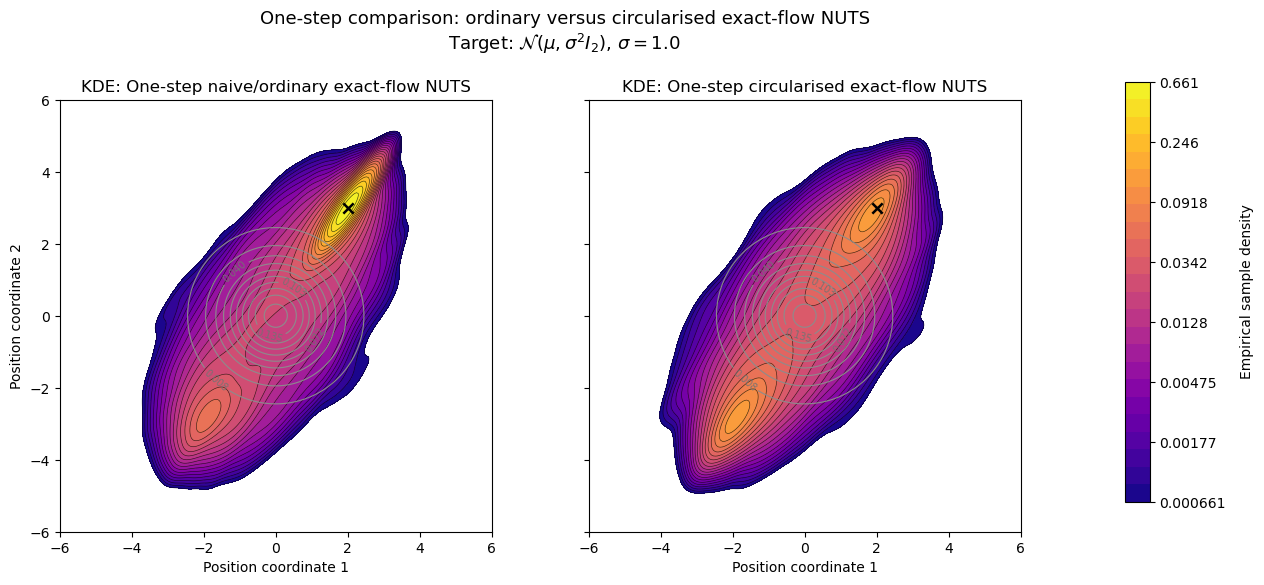

In [31]:
n_iter = 100000
dimension = 2
sigma = 1.0
one_step_samples = np.empty((n_iter, 2))
initial_position = np.array([2.0, 3.0])  # starting point for the Markov chain

ordinary_sampler = ordinary_GIST_NUTS_continuous_isotropic(
    dimension=dimension,
    sigma=sigma,
    mean=np.zeros(dimension),
    uturn_condition="distance",
    seed=0,
)

circularised_sampler = (
    circularised_GIST_NUTS_continuous_isotropic(
        dimension=dimension,
        sigma=sigma,
        mean=np.zeros(dimension),
        m=1.0,
        eta=1.0,
        seed=1,
    )
)

one_step_result = compare_gist_kde(
    ordinary_sampler=ordinary_sampler,
    circularised_sampler=circularised_sampler,
    initial_position=initial_position,
    n_samples=n_iter,
    burn_in=0,
    thin=1,
    focus="1-step",
    plot_range=((-6, 6), (-6, 6)),
    kde_bw_adjust=1.2,
    kde_levels=25,
    seed=0,
)

plt.show()


---

## Ensemble \(n\)-step mixing comparison

The one-step plots estimate the transition law $P(x_0,\cdot)$. To examine how the two kernels move toward the target over several transitions, this section propagates an ensemble of independent replicas, all starting from the same position $x_0$. For every replica, the draw obtained after jump $r-1$ is used as the initial position for jump $r$. The samples stored at jump $r$ therefore estimate the $r$-step law
$$
P^r(x_0,\cdot)
$$

The KDE figures place ordinary NUTS and weighted circularised NUTS side by side. Within each jump number, both panels share the same absolute KDE colour scale. The target $\mathcal N(0,I_2)$ is overlaid using reference contours.

KDE snapshots are useful visual diagnostics, but they do not by themselves constitute a complete mixing-rate analysis. The final functions also report the errors in the empirical mean, covariance matrix, and second moment at each jump.


### Correction to the ensemble KDE display

At the first jump, the ordinary NUTS KDE has a much higher peak than the circularised KDE, so this removed a large part of the circularised low-density body. The corrected version retains a shared colour normalization, but applies the display threshold relative to each KDE's own maximum and uses a logarithmic density scale.

In [32]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize


def sample_n_step_gist_ensembles(
    x0,
    n_chains=10_000,
    n_jumps=10,
    sigma=1.0,
    mean=None,
    m=1.0,
    eta=1.0,
    root_tolerance=1e-10,
    rank_rtol=1e-12,
    seed=2026,
    circularised_mode="reduced",
    verbose=True,
):
    """
    Propagate independent ensembles from a common initial position.

    Parameters
    ----------
    x0:
        Common initial position.

    n_chains:
        Number of independent replicas.

    n_jumps:
        Number of GIST transitions applied to every replica.

    sigma, mean:
        Parameters of N(mean, sigma^2 I_d).

    circularised_mode:
        "reduced":
            Use the analytic circularised update

                theta ~ Uniform(0, pi),
                x+ = mean + cos(theta)(x-mean)
                     + sigma sin(theta) p.

            This is substantially faster and is the recommended mode.

        "class":
            Apply the circularised sampler's transition method directly.
            This also constructs the trajectory-dependent matrix W.

    Returns
    -------
    result:
        ``ordinary`` and ``circularised`` have shape

            (n_jumps, n_chains, dimension).

        The entry at index r-1 approximates the r-step transition law
        from x0.
    """
    x0 = np.asarray(x0, dtype=float)

    if x0.ndim != 1 or x0.size < 2:
        raise ValueError(
            "x0 must be a one-dimensional vector with dimension >= 2."
        )

    if not isinstance(n_chains, (int, np.integer)) or n_chains < 2:
        raise ValueError(
            "n_chains must be an integer greater than 1."
        )

    if not isinstance(n_jumps, (int, np.integer)) or n_jumps < 1:
        raise ValueError(
            "n_jumps must be a positive integer."
        )

    if not np.isfinite(sigma) or sigma <= 0:
        raise ValueError(
            "sigma must be positive and finite."
        )

    if circularised_mode not in {"reduced", "class"}:
        raise ValueError(
            "circularised_mode must be 'reduced' or 'class'."
        )

    dimension = x0.size

    if mean is None:
        mean = np.zeros(dimension)
    else:
        mean = np.asarray(mean, dtype=float)

        if mean.shape != (dimension,):
            raise ValueError(
                f"mean must have shape ({dimension},)."
            )

    # Independent, reproducible random streams for the two methods.
    seed_sequence = np.random.SeedSequence(seed)
    ordinary_seed_sequence, circular_seed_sequence = (
        seed_sequence.spawn(2)
    )

    ordinary_seed = int(
        ordinary_seed_sequence.generate_state(1)[0]
    )
    circular_seed = int(
        circular_seed_sequence.generate_state(1)[0]
    )

    ordinary_sampler = ordinary_GIST_NUTS_continuous_isotropic(
        dimension=dimension,
        sigma=sigma,
        mean=mean,
        uturn_condition="distance",
        root_tolerance=root_tolerance,
        seed=ordinary_seed,
    )

    circular_rng = np.random.default_rng(
        circular_seed
    )

    if circularised_mode == "class":
        circularised_sampler = (
            circularised_GIST_NUTS_continuous_isotropic(
                dimension=dimension,
                sigma=sigma,
                mean=mean,
                m=m,
                eta=eta,
                root_tolerance=root_tolerance,
                rank_rtol=rank_rtol,
                seed=circular_seed,
            )
        )
    else:
        circularised_sampler = None

    ordinary = np.empty(
        (n_jumps, n_chains, dimension),
        dtype=float,
    )

    circularised = np.empty_like(ordinary)

    ordinary_accepted = np.empty(
        (n_jumps, n_chains),
        dtype=bool,
    )

    ordinary_acceptance_probability = np.empty(
        (n_jumps, n_chains),
        dtype=float,
    )

    ordinary_tau_1 = np.empty(
        (n_jumps, n_chains),
        dtype=float,
    )

    circularised_accepted = np.ones(
        (n_jumps, n_chains),
        dtype=bool,
    )

    ordinary_current = np.repeat(
        x0[None, :],
        n_chains,
        axis=0,
    )

    circularised_current = ordinary_current.copy()

    for jump in range(n_jumps):
        # ----------------------------------------------------
        # Ordinary GIST: apply one transition independently to
        # every current state.
        # ----------------------------------------------------
        ordinary_updated = np.empty_like(
            ordinary_current
        )

        for chain in range(n_chains):
            state, information = (
                ordinary_sampler.transition(
                    ordinary_current[chain]
                )
            )

            ordinary_updated[chain] = state
            ordinary_accepted[jump, chain] = (
                information["accepted"]
            )
            ordinary_acceptance_probability[
                jump, chain
            ] = information[
                "acceptance_probability"
            ]
            ordinary_tau_1[jump, chain] = (
                information["tau_1"]
            )

        ordinary_current = ordinary_updated
        ordinary[jump] = ordinary_current

        # ----------------------------------------------------
        # Circularised GIST
        # ----------------------------------------------------
        if circularised_mode == "reduced":
            momenta = circular_rng.normal(
                size=(n_chains, dimension)
            )

            theta = circular_rng.uniform(
                0.0,
                np.pi,
                size=n_chains,
            )

            circularised_current = (
                mean[None, :]
                + np.cos(theta)[:, None]
                * (
                    circularised_current
                    - mean[None, :]
                )
                + sigma
                * np.sin(theta)[:, None]
                * momenta
            )

        else:
            circularised_updated = np.empty_like(
                circularised_current
            )

            for chain in range(n_chains):
                state, information = (
                    circularised_sampler.transition(
                        circularised_current[chain]
                    )
                )

                circularised_updated[chain] = state
                circularised_accepted[
                    jump, chain
                ] = information["accepted"]

            circularised_current = (
                circularised_updated
            )

        circularised[jump] = (
            circularised_current
        )

        if verbose:
            print(
                f"Completed jump {jump + 1}/{n_jumps}: "
                f"ordinary acceptance rate = "
                f"{ordinary_accepted[jump].mean():.3f}"
            )

    return {
        "x0": x0,
        "mean": mean,
        "sigma": float(sigma),
        "ordinary": ordinary,
        "circularised": circularised,
        "ordinary_accepted": ordinary_accepted,
        "ordinary_acceptance_probability": (
            ordinary_acceptance_probability
        ),
        "ordinary_tau_1": ordinary_tau_1,
        "circularised_accepted": (
            circularised_accepted
        ),
        "n_chains": int(n_chains),
        "n_jumps": int(n_jumps),
        "seed": int(seed),
        "ordinary_sampling_seed": (
            ordinary_seed
        ),
        "circularised_sampling_seed": (
            circular_seed
        ),
        "circularised_mode": circularised_mode,
    }


def plot_n_step_gist_kde_comparison(
    result,
    jump_numbers=None,
    plot_range=((-6, 6), (-6, 6)),
    gridsize=250,
    kde_max_points=10_000,
    kde_levels=25,
    kde_bw_adjust=1.2,
    density_floor_ratio=1e-3,
    rows_per_figure=10,
    scale_mode="per_jump",
    density_norm="log",
    show_target=True,
    target_levels=10,
    cmap="plasma",
    figure_width=12.5,
    row_height=4.8,
    colorbar_ticks=7,
):
    """
    Plot the r-step ordinary and circularised GIST laws.

    The layout follows the attached multi-step NUTS notebook:
    every row contains

        ordinary KDE | circularised KDE | row-specific colour bar.

    Within a row, the two methods use the same KDE grid, bandwidth,
    contour levels, and colour normalization. A narrow empty GridSpec
    column provides additional separation before the colour bar.
    """
    ordinary = np.asarray(
        result["ordinary"],
        dtype=float,
    )
    circularised = np.asarray(
        result["circularised"],
        dtype=float,
    )

    if ordinary.shape != circularised.shape:
        raise ValueError(
            "ordinary and circularised arrays must have identical shapes."
        )

    if ordinary.ndim != 3 or ordinary.shape[2] < 2:
        raise ValueError(
            "sample arrays must have shape "
            "(n_jumps, n_chains, dimension), dimension >= 2."
        )

    if rows_per_figure < 1:
        raise ValueError(
            "rows_per_figure must be positive."
        )

    if scale_mode not in {"per_jump", "global"}:
        raise ValueError(
            "scale_mode must be 'per_jump' or 'global'."
        )

    if density_norm not in {"linear", "log"}:
        raise ValueError(
            "density_norm must be 'linear' or 'log'."
        )

    if not (
        np.isfinite(density_floor_ratio)
        and 0.0 < density_floor_ratio < 1.0
    ):
        raise ValueError(
            "density_floor_ratio must lie strictly between 0 and 1."
        )

    n_available = ordinary.shape[0]

    if jump_numbers is None:
        jump_numbers = list(
            range(1, n_available + 1)
        )
    else:
        jump_numbers = [
            int(value)
            for value in jump_numbers
        ]

    if not jump_numbers:
        raise ValueError(
            "jump_numbers cannot be empty."
        )

    if (
        min(jump_numbers) < 1
        or max(jump_numbers) > n_available
    ):
        raise ValueError(
            f"jump_numbers must lie between 1 and {n_available}."
        )

    x_grid = np.linspace(
        plot_range[0][0],
        plot_range[0][1],
        gridsize,
    )

    y_grid = np.linspace(
        plot_range[1][0],
        plot_range[1][1],
        gridsize,
    )

    X, Y = np.meshgrid(
        x_grid,
        y_grid,
    )

    target_density = (
        _isotropic_gaussian_density(
            X,
            Y,
            mean=result["mean"][:2],
            sigma=result["sigma"],
        )
    )

    maximum_target_density = float(
        np.max(target_density)
    )

    target_density_levels = np.linspace(
        0.05 * maximum_target_density,
        0.95 * maximum_target_density,
        target_levels,
    )

    selected_samples = {}
    kde_values = {}

    base_seed = int(
        result.get("seed", 0)
    )

    for jump in jump_numbers:
        index = jump - 1

        for method, offset in [
            ("ordinary", 101),
            ("circularised", 202),
        ]:
            samples = (
                ordinary[index]
                if method == "ordinary"
                else circularised[index]
            )

            density, selected, kde = (
                _evaluate_kde_on_grid(
                    samples,
                    X,
                    Y,
                    max_points=kde_max_points,
                    bw_adjust=kde_bw_adjust,
                    seed=(
                        base_seed
                        + offset
                        + index
                    ),
                )
            )

            selected_samples[
                (method, jump)
            ] = selected

            kde_values[
                (method, jump)
            ] = density

    if scale_mode == "global":
        global_maximum = max(
            float(np.max(density))
            for density in kde_values.values()
        )

        global_minimum = max(
            density_floor_ratio
            * global_maximum,
            np.finfo(float).tiny,
        )
    else:
        global_maximum = None
        global_minimum = None

    figures = []

    for start in range(
        0,
        len(jump_numbers),
        rows_per_figure,
    ):
        displayed_jumps = jump_numbers[
            start:start + rows_per_figure
        ]

        n_rows = len(displayed_jumps)

        fig = plt.figure(
            figsize=(
                figure_width,
                row_height * n_rows + 1.0,
            ),
            facecolor="white",
            constrained_layout=True,
        )

        # Column 2 is intentionally left empty to create a visible
        # margin between the right KDE panel and the colour bar.
        grid = fig.add_gridspec(
            nrows=n_rows,
            ncols=4,
            width_ratios=(
                1.0,
                1.0,
                0.075,
                0.045,
            ),
            wspace=0.10,
            hspace=0.18,
        )

        for row, jump in enumerate(
            displayed_jumps
        ):
            ordinary_axis = fig.add_subplot(
                grid[row, 0]
            )
            circularised_axis = fig.add_subplot(
                grid[row, 1]
            )
            colour_bar_axis = fig.add_subplot(
                grid[row, 3]
            )

            ordinary_density = kde_values[
                ("ordinary", jump)
            ]

            circularised_density = kde_values[
                ("circularised", jump)
            ]

            if scale_mode == "global":
                minimum_density = global_minimum
                maximum_density = global_maximum
            else:
                maximum_density = max(
                    float(
                        np.max(
                            ordinary_density
                        )
                    ),
                    float(
                        np.max(
                            circularised_density
                        )
                    ),
                )

                minimum_density = max(
                    density_floor_ratio
                    * maximum_density,
                    np.finfo(float).tiny,
                )

            if density_norm == "log":
                normalization = LogNorm(
                    vmin=minimum_density,
                    vmax=maximum_density,
                )

                density_levels = np.geomspace(
                    minimum_density,
                    maximum_density,
                    kde_levels,
                )

                ticks = np.geomspace(
                    minimum_density,
                    maximum_density,
                    colorbar_ticks,
                )

            else:
                normalization = Normalize(
                    vmin=0.0,
                    vmax=maximum_density,
                )

                density_levels = np.linspace(
                    minimum_density,
                    maximum_density,
                    kde_levels,
                )

                ticks = np.linspace(
                    0.0,
                    maximum_density,
                    colorbar_ticks,
                )

            panels = [
                (
                    ordinary_axis,
                    ordinary_density,
                    "Ordinary exact-flow GIST/NUTS",
                ),
                (
                    circularised_axis,
                    circularised_density,
                    "Circularised exact-flow GIST/NUTS",
                ),
            ]

            for column, (
                axis,
                density,
                title,
            ) in enumerate(panels):
                axis.set_facecolor("white")

                density_for_plot = (
                    np.ma.masked_less_equal(
                        density,
                        minimum_density,
                    )
                )

                axis.contourf(
                    X,
                    Y,
                    density_for_plot,
                    levels=density_levels,
                    cmap=cmap,
                    norm=normalization,
                    zorder=1,
                )

                axis.contour(
                    X,
                    Y,
                    density_for_plot,
                    levels=density_levels,
                    colors="black",
                    linewidths=0.45,
                    alpha=0.70,
                    zorder=2,
                )

                if show_target:
                    target_contours = axis.contour(
                        X,
                        Y,
                        target_density,
                        levels=target_density_levels,
                        colors="0.55",
                        linewidths=0.80,
                        linestyles="-",
                        alpha=0.95,
                        zorder=3,
                    )

                    axis.clabel(
                        target_contours,
                        target_contours.levels[::2],
                        inline=True,
                        fontsize=6,
                        fmt="%.3f",
                        colors="0.45",
                    )

                axis.scatter(
                    result["x0"][0],
                    result["x0"][1],
                    marker="x",
                    s=38,
                    linewidths=1.5,
                    color="black",
                    zorder=4,
                )

                axis.set_xlim(
                    *plot_range[0]
                )
                axis.set_ylim(
                    *plot_range[1]
                )

                axis.set_aspect(
                    "equal",
                    adjustable="box",
                )

                axis.set_xlabel(
                    "Position coordinate 1"
                )

                axis.set_ylabel(
                    "Position coordinate 2"
                    if column == 0
                    else ""
                )

                axis.set_title(
                    f"{jump}-step distribution: {title}",
                    fontsize=10,
                    pad=7,
                )

                axis.grid(False)
                axis.tick_params(
                    labelsize=8
                )

            mappable = ScalarMappable(
                norm=normalization,
                cmap=cmap,
            )
            mappable.set_array([])

            colour_bar = fig.colorbar(
                mappable,
                cax=colour_bar_axis,
                ticks=ticks,
            )

            colour_bar.set_label(
                (
                    "Empirical KDE density\n"
                    f"(shared scale, step {jump})"
                ),
                fontsize=8,
                labelpad=8,
            )

            colour_bar.ax.set_yticklabels(
                [
                    f"{value:.3g}"
                    for value in ticks
                ]
            )

            colour_bar.ax.tick_params(
                labelsize=7
            )

        fig.suptitle(
            (
                "Ensemble propagation from a common initial "
                "position under "
                r"$\mathcal{N}(\mu,\sigma^2I_2)$"
                "\n"
                rf"$\sigma={result['sigma']}$, "
                rf"$n={result['n_chains']}$ independent replicas"
            ),
            fontsize=12,
        )

        figures.append(fig)

    return {
        "figures": figures,
        "X": X,
        "Y": Y,
        "kde_values": kde_values,
        "selected_samples": selected_samples,
        "target_density": target_density,
    }

In [33]:
import pandas as pd

def isotropic_gaussian_2d_pdf(
    points,
    mean,
    sigma,
):
    """
    Evaluate the N(mean, sigma^2 I_2) density.
    """
    points = np.asarray(
        points,
        dtype=float,
    )

    mean = np.asarray(
        mean,
        dtype=float,
    )

    if points.ndim != 2 or points.shape[1] != 2:
        raise ValueError(
            "points must have shape (n_points, 2)."
        )

    if mean.shape != (2,):
        raise ValueError(
            "mean must have shape (2,)."
        )

    squared_distance = np.sum(
        (points - mean[None, :])**2,
        axis=1,
    )

    return (
        np.exp(
            -squared_distance
            / (2.0 * sigma**2)
        )
        / (2.0 * np.pi * sigma**2)
    )


def kde_tv_distance_to_target_mc(
    kde,
    mean,
    sigma,
    n_integration_samples=10_000,
    seed=0,
):
    """
    Estimate TV(KDE, N(mean, sigma^2 I_2)) by stratified mixture
    importance sampling.

    The proposal is

        q = 0.5 * KDE + 0.5 * target.

    Returns
    -------
    estimate:
        Monte Carlo estimate of the KDE-based TV distance.

    standard_error:
        Conditional Monte Carlo standard error of the integration.
    """
    if (
        not isinstance(
            n_integration_samples,
            (int, np.integer),
        )
        or n_integration_samples < 4
    ):
        raise ValueError(
            "n_integration_samples must be an integer at least 4."
        )

    mean = np.asarray(
        mean,
        dtype=float,
    )

    if mean.shape != (2,):
        raise ValueError(
            "mean must have shape (2,)."
        )

    rng = np.random.default_rng(seed)

    n_kde = n_integration_samples // 2
    n_target = (
        n_integration_samples - n_kde
    )

    kde_seed = int(
        rng.integers(
            0,
            np.iinfo(np.int32).max,
        )
    )

    points_kde = kde.resample(
        size=n_kde,
        seed=kde_seed,
    ).T

    points_target = (
        mean[None, :]
        + sigma
        * rng.normal(
            size=(n_target, 2)
        )
    )

    def integrand(points):
        fitted_density = kde(
            points.T
        )

        target_density = (
            isotropic_gaussian_2d_pdf(
                points,
                mean=mean,
                sigma=sigma,
            )
        )

        denominator = np.maximum(
            fitted_density + target_density,
            np.finfo(float).tiny,
        )

        return (
            np.abs(
                fitted_density
                - target_density
            )
            / denominator
        )

    values_from_kde = integrand(
        points_kde
    )

    values_from_target = integrand(
        points_target
    )

    # Stratified estimate under
    # q = 0.5 p_hat + 0.5 pi.
    estimate = 0.5 * (
        np.mean(values_from_kde)
        + np.mean(values_from_target)
    )

    standard_error = np.sqrt(
        0.25
        * np.var(
            values_from_kde,
            ddof=1,
        )
        / n_kde
        + 0.25
        * np.var(
            values_from_target,
            ddof=1,
        )
        / n_target
    )

    return (
        float(estimate),
        float(standard_error),
    )


def n_step_gist_kde_tv_diagnostics(
    result,
    kde_max_points=5_000,
    kde_bw_adjust=1.2,
    n_integration_samples=10_000,
    seed=2026,
):
    """
    Estimate the KDE-based TV distance to the isotropic Gaussian
    target after every GIST transition.
    """
    diagnostics = {}

    seed_sequence = np.random.SeedSequence(
        seed
    )

    method_sequences = seed_sequence.spawn(2)

    for method_index, method in enumerate(
        ["ordinary", "circularised"]
    ):
        samples = np.asarray(
            result[method],
            dtype=float,
        )

        n_jumps = samples.shape[0]

        distances = np.empty(
            n_jumps
        )

        standard_errors = np.empty(
            n_jumps
        )

        jump_sequences = (
            method_sequences[
                method_index
            ].spawn(n_jumps)
        )

        for jump in range(n_jumps):
            rng = np.random.default_rng(
                jump_sequences[jump]
            )

            selected_samples = (
                _select_kde_samples(
                    samples[jump],
                    max_points=kde_max_points,
                    seed=int(
                        rng.integers(
                            0,
                            np.iinfo(
                                np.int32
                            ).max,
                        )
                    ),
                )
            )

            kde = _fit_gaussian_kde(
                selected_samples,
                bw_adjust=kde_bw_adjust,
                jitter_seed=int(
                    rng.integers(
                        0,
                        np.iinfo(
                            np.int32
                        ).max,
                    )
                ),
            )

            integration_seed = int(
                rng.integers(
                    0,
                    np.iinfo(np.int32).max,
                )
            )

            distance, standard_error = (
                kde_tv_distance_to_target_mc(
                    kde=kde,
                    mean=result["mean"][:2],
                    sigma=result["sigma"],
                    n_integration_samples=(
                        n_integration_samples
                    ),
                    seed=integration_seed,
                )
            )

            distances[jump] = distance
            standard_errors[jump] = (
                standard_error
            )

            print(
                f"{method}, step {jump + 1}: "
                f"TV = {distance:.4f} "
                f"(MC SE = {standard_error:.4f})"
            )

        diagnostics[method] = {
            "tv_distance": distances,
            "mc_standard_error": (
                standard_errors
            ),
        }

    diagnostics["settings"] = {
        "kde_max_points": (
            int(kde_max_points)
        ),
        "kde_bw_adjust": float(
            kde_bw_adjust
        ),
        "n_integration_samples": int(
            n_integration_samples
        ),
    }

    return diagnostics


def n_step_gist_tv_table(
    diagnostics,
):
    """
    Return a tidy table of the stepwise TV estimates.
    """
    n_jumps = len(
        diagnostics["ordinary"][
            "tv_distance"
        ]
    )

    rows = []

    for jump in range(n_jumps):
        for method, label in [
            (
                "ordinary",
                "Ordinary exact-flow GIST/NUTS",
            ),
            (
                "circularised",
                "Circularised exact-flow GIST/NUTS",
            ),
        ]:
            distance = diagnostics[
                method
            ]["tv_distance"][jump]

            standard_error = diagnostics[
                method
            ]["mc_standard_error"][jump]

            rows.append(
                {
                    "step": jump + 1,
                    "method": label,
                    "tv_estimate": distance,
                    "mc_standard_error": (
                        standard_error
                    ),
                    "ci_lower_95": max(
                        0.0,
                        distance
                        - 1.96
                        * standard_error,
                    ),
                    "ci_upper_95": min(
                        1.0,
                        distance
                        + 1.96
                        * standard_error,
                    ),
                }
            )

    return pd.DataFrame(rows)


def plot_n_step_gist_tv_diagnostics(
    result,
    diagnostics=None,
    kde_max_points=5_000,
    kde_bw_adjust=1.2,
    n_integration_samples=10_000,
    seed=2026,
    figsize=(8, 6),
):
    """
    Plot stepwise KDE-based TV distance with conditional 95 percent
    Monte Carlo error bars.
    """
    if diagnostics is None:
        diagnostics = (
            n_step_gist_kde_tv_diagnostics(
                result=result,
                kde_max_points=(
                    kde_max_points
                ),
                kde_bw_adjust=(
                    kde_bw_adjust
                ),
                n_integration_samples=(
                    n_integration_samples
                ),
                seed=seed,
            )
        )

    jumps = np.arange(
        1,
        result["n_jumps"] + 1,
    )

    fig, axis = plt.subplots(
        figsize=figsize
    )

    for method, marker, label in [
        (
            "ordinary",
            "o",
            "Ordinary exact-flow GIST/NUTS",
        ),
        (
            "circularised",
            "s",
            "Circularised exact-flow GIST/NUTS",
        ),
    ]:
        distance = diagnostics[
            method
        ]["tv_distance"]

        standard_error = diagnostics[
            method
        ]["mc_standard_error"]

        axis.errorbar(
            jumps,
            distance,
            yerr=1.96 * standard_error,
            marker=marker,
            linewidth=1.8,
            capsize=3,
            label=label,
        )

    axis.set_xlabel(
        "Number of GIST transitions"
    )

    axis.set_ylabel(
        r"Estimated "
        r"$d_{\mathrm{TV}}"
        r"(\widehat P_r,"
        r"\mathcal{N}(\mu,\sigma^2I_2))$"
    )

    axis.set_title(
        "KDE-based total variation distance to the target"
    )

    axis.set_xticks(jumps)
    axis.set_ylim(0.0, 1.0)
    axis.grid(alpha=0.30)
    axis.legend()

    fig.tight_layout()
    plt.show()

    return {
        "diagnostics": diagnostics,
        "table": n_step_gist_tv_table(
            diagnostics
        ),
        "figure": fig,
        "axis": axis,
    }

Completed jump 1/10: ordinary acceptance rate = 0.645
Completed jump 2/10: ordinary acceptance rate = 0.659
Completed jump 3/10: ordinary acceptance rate = 0.667
Completed jump 4/10: ordinary acceptance rate = 0.673
Completed jump 5/10: ordinary acceptance rate = 0.680
Completed jump 6/10: ordinary acceptance rate = 0.684
Completed jump 7/10: ordinary acceptance rate = 0.684
Completed jump 8/10: ordinary acceptance rate = 0.689
Completed jump 9/10: ordinary acceptance rate = 0.689
Completed jump 10/10: ordinary acceptance rate = 0.691


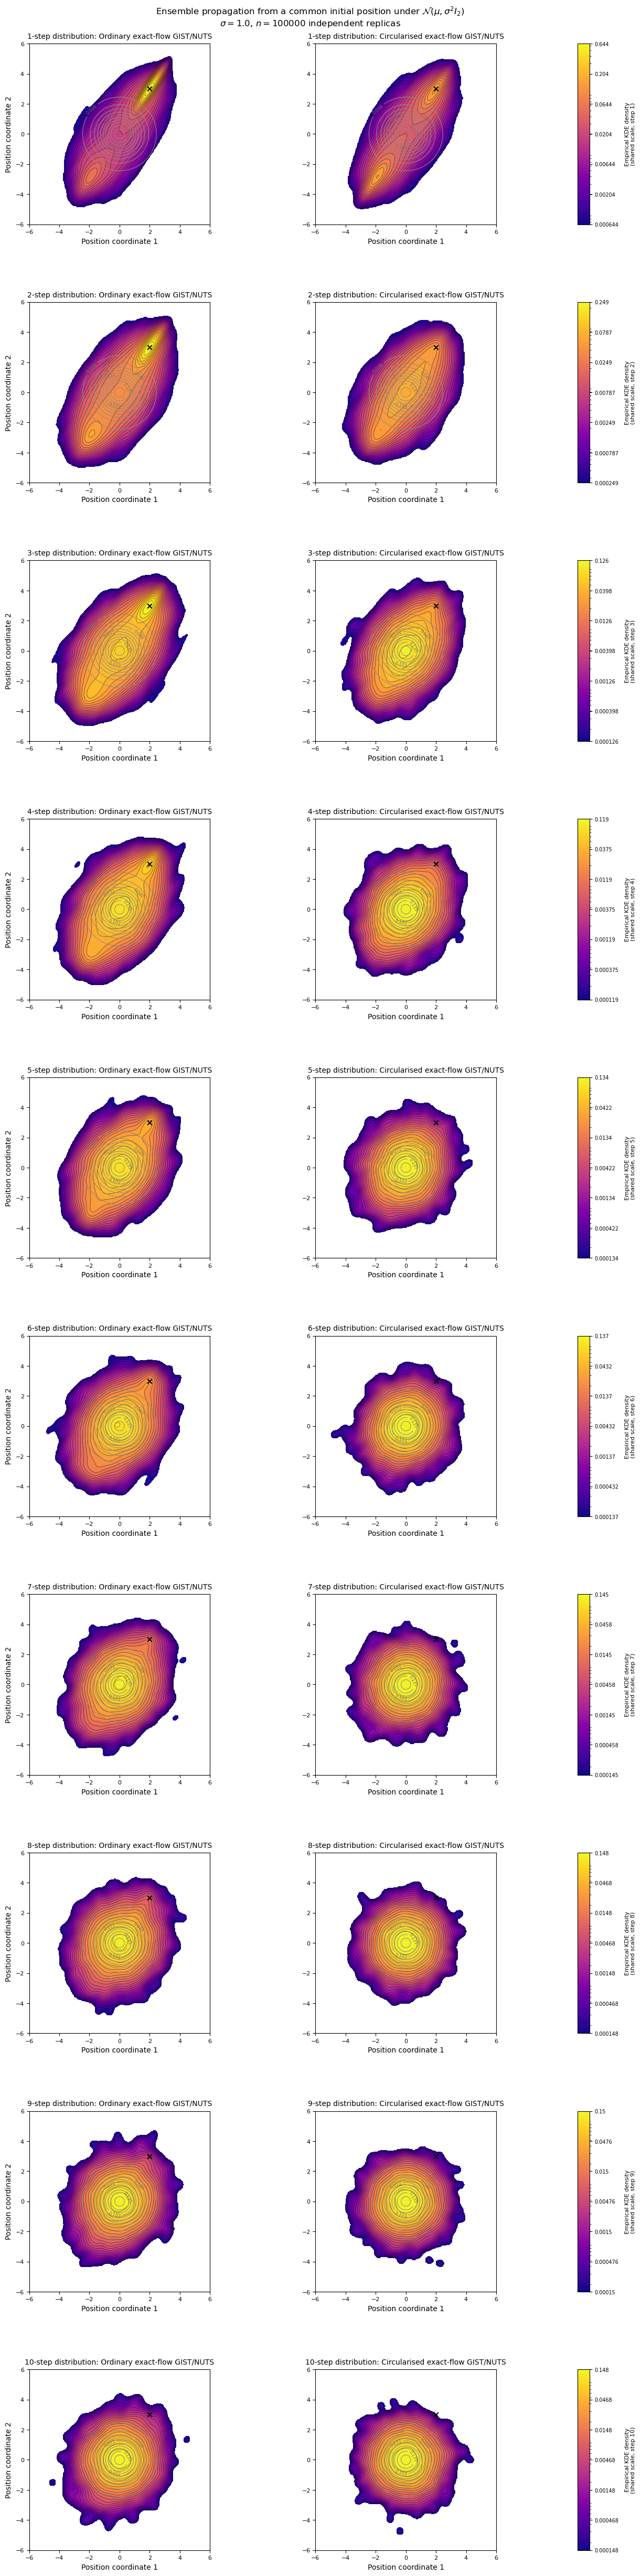

ordinary, step 1: TV = 0.7111 (MC SE = 0.0023)
ordinary, step 2: TV = 0.5483 (MC SE = 0.0025)
ordinary, step 3: TV = 0.4393 (MC SE = 0.0025)
ordinary, step 4: TV = 0.3260 (MC SE = 0.0024)
ordinary, step 5: TV = 0.2476 (MC SE = 0.0022)
ordinary, step 6: TV = 0.1777 (MC SE = 0.0018)
ordinary, step 7: TV = 0.1439 (MC SE = 0.0015)
ordinary, step 8: TV = 0.1110 (MC SE = 0.0012)
ordinary, step 9: TV = 0.0921 (MC SE = 0.0010)
ordinary, step 10: TV = 0.0700 (MC SE = 0.0008)
circularised, step 1: TV = 0.6076 (MC SE = 0.0024)
circularised, step 2: TV = 0.3968 (MC SE = 0.0024)
circularised, step 3: TV = 0.2433 (MC SE = 0.0020)
circularised, step 4: TV = 0.1450 (MC SE = 0.0015)
circularised, step 5: TV = 0.0922 (MC SE = 0.0010)
circularised, step 6: TV = 0.0693 (MC SE = 0.0008)
circularised, step 7: TV = 0.0482 (MC SE = 0.0005)
circularised, step 8: TV = 0.0478 (MC SE = 0.0005)
circularised, step 9: TV = 0.0384 (MC SE = 0.0005)
circularised, step 10: TV = 0.0345 (MC SE = 0.0004)


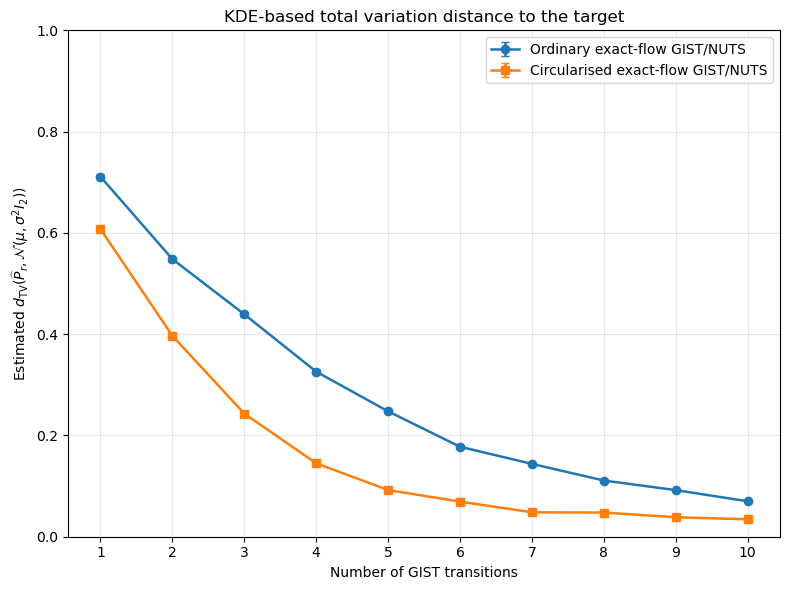

,step,method,tv_estimate,mc_standard_error,ci_lower_95,ci_upper_95
0,1,Ordinary exact-flow GIST/NUTS,0.711057,0.002308,0.706534,0.715580
1,1,Circularised exact-flow GIST/NUTS,0.607631,0.002435,0.602858,0.612403
2,2,Ordinary exact-flow GIST/NUTS,0.548273,0.002506,0.543361,0.553185
3,2,Circularised exact-flow GIST/NUTS,0.396826,0.002412,0.392098,0.401554
4,3,Ordinary exact-flow GIST/NUTS,0.439294,0.002513,0.434368,0.444221
5,3,Circularised exact-flow GIST/NUTS,0.243250,0.001996,0.239338,0.247163
6,4,Ordinary exact-flow GIST/NUTS,0.325979,0.002371,0.321331,0.330627
7,4,Circularised exact-flow GIST/NUTS,0.144970,0.001520,0.141990,0.147950
8,5,Ordinary exact-flow GIST/NUTS,0.247618,0.002160,0.243385,0.251851
9,5,Circularised exact-flow GIST/NUTS,0.092200,0.001048,0.090146,0.094255


In [35]:
# ============================================================
# Run the 1- to 10-step ensemble experiment
# ============================================================

RUN_N_STEP_GIST_MIXING = True
RUN_N_STEP_GIST_TV = True

if RUN_N_STEP_GIST_MIXING:
    n_step_gist_result = (
        sample_n_step_gist_ensembles(
            x0=np.array([2.0, 3.0]),
            n_chains=100000,
            n_jumps=10,
            sigma=1.0,
            mean=np.zeros(2),
            seed=0,
            circularised_mode="reduced",
            verbose=True,
        )
    )

    n_step_gist_kde_result = (
        plot_n_step_gist_kde_comparison(
            n_step_gist_result,
            jump_numbers=range(1, 11),
            plot_range=(
                (-6, 6),
                (-6, 6),
            ),
            gridsize=250,
            kde_max_points=10000,
            kde_levels=25,
            kde_bw_adjust=1.2,
            density_floor_ratio=1e-3,
            rows_per_figure=10,
            scale_mode="per_jump",
            density_norm="log",
            show_target=True,
            target_levels=10,
            figure_width=12.5,
            row_height=4.8,
            colorbar_ticks=7,
        )
    )

    plt.show()


if RUN_N_STEP_GIST_TV:
    # The TV calculation is computationally more expensive than the
    # KDE heatmap. Increase these values for a more precise estimate.
    n_step_gist_tv = (
        plot_n_step_gist_tv_diagnostics(
            result=n_step_gist_result,
            kde_max_points=5000,
            kde_bw_adjust=1.2,
            n_integration_samples=10000,
            seed=2026,
        )
    )

    display(
        n_step_gist_tv["table"]
    )

---

In [ ]:
from scipy.optimize import brentq
from typing import Optional

class ordinary_GIST_NUTS_continuous:
    """
    Ordinary one-sided exact-flow GIST sampler for a Gaussian target.

    Target
    ------
        x ~ N(mean, covariance)

    Momentum
    --------
        p ~ N(0, I_d)

    At every transition:

    1. Refresh p ~ N(0, I_d).
    2. Compute the first one-sided U-turn time

           tau_1 = tau(x, p).

    3. Sample

           alpha ~ Uniform(0, tau_1).

    4. Follow the exact Hamiltonian flow for time alpha:

           (x_alpha, p_alpha) = phi_alpha(x, p).

    5. Apply momentum reversal:

           (x_proposed, p_proposed) = (x_alpha, -p_alpha).

    6. Compute

           tau_2 = tau(x_proposed, p_proposed).

    7. Accept with probability

           min(1, tau_1 / tau_2) * 1{tau_2 >= alpha}.

    Parameters
    ----------
    covariance:
        Symmetric positive-definite Gaussian covariance matrix.

    mean:
        Gaussian mean. Defaults to zero.

    uturn_condition:
        Either:

        "distance":
            Stops at the first positive root of

                (x_t - x_0)^T p_t = 0.

            This corresponds to the distance-based criterion in
            Equation (6) of the GIST paper.

        "angle":
            Stops at the first positive root of

                p_0^T p_t = 0.

            This corresponds to the angle-based criterion in
            Equation (5) of the GIST paper.

    scan_step:
        Grid spacing used only to bracket the first root before
        applying Brent's root-finding method. It is not an HMC
        integration step, because the Hamiltonian flow is exact.

    max_time:
        Maximum time searched for a U-turn.

    root_tolerance:
        Numerical tolerance used by the root solver.

    seed:
        Random-number-generator seed.
    """

    def __init__(
        self,
        covariance: np.ndarray,
        mean: Optional[np.ndarray] = None,
        uturn_condition: str = "distance",
        scan_step: Optional[float] = None,
        max_time: Optional[float] = None,
        root_tolerance: float = 1e-12,
        seed: Optional[int] = None,
    ) -> None:

        covariance = np.asarray(covariance, dtype=float)  # convert to float array

        if covariance.ndim == 0:
            covariance = covariance.reshape(1, 1)

        if (
            covariance.ndim != 2
            or covariance.shape[0] != covariance.shape[1]
        ):
            raise ValueError(
                "covariance must be a square matrix."
            )

        # Check the symmetry of covariance
        if not np.allclose(
            covariance,
            covariance.T,
            atol=1e-12,
            rtol=1e-12,
        ):
            raise ValueError(
                "covariance must be symmetric."
            )

        eigenvalues, eigenvectors = np.linalg.eigh(covariance)

        if np.any(eigenvalues <= 0):
            raise ValueError(
                "covariance must be positive definite."
            )

        self.covariance = covariance
        self.dimension = covariance.shape[0]

        if mean is None:
            self.mean = np.zeros(self.dimension)  # default to zero mean
        else:
            self.mean = np.asarray(mean, dtype=float)

            if self.mean.shape != (self.dimension,):
                raise ValueError(
                    f"mean must have shape ({self.dimension},)."
                )

        if uturn_condition not in {"distance", "angle"}:
            raise ValueError(
                "uturn_condition must be either "
                "'distance' or 'angle'."
            )  # ensure the uturn_condition is either "distance" or "angle"

        self.uturn_condition = uturn_condition

        # Sigma = Q diag(sigma_i^2) Q^T
        self.eigenvalues = eigenvalues
        self.eigenvectors = eigenvectors
        self.standard_deviations = np.sqrt(eigenvalues)

        self.root_tolerance = float(root_tolerance)

        if self.root_tolerance <= 0:
            raise ValueError(
                "root_tolerance must be positive."
            )

        # Resolve the fastest oscillation sufficiently finely.
        if scan_step is None:
            self.scan_step = (
                np.pi
                * np.min(self.standard_deviations)
                / 64.0
            )
        else:
            self.scan_step = float(scan_step)

        if self.scan_step <= 0:
            raise ValueError(
                "scan_step must be positive."
            )

        if max_time is None:
            self.max_time = (
                10.0
                * np.pi
                * np.max(self.standard_deviations)
            )
        else:
            self.max_time = float(max_time)

        if self.max_time <= 0:
            raise ValueError(
                "max_time must be positive."
            )

        self.rng = np.random.default_rng(seed)

    # ========================================================
    # Validation
    # ========================================================

    def _validate_vector(
        self,
        value: np.ndarray,
        name: str,
    ) -> np.ndarray:
        value = np.asarray(value, dtype=float)

        if value.shape != (self.dimension,):
            raise ValueError(
                f"{name} must have shape "
                f"({self.dimension},)."
            )

        if not np.all(np.isfinite(value)):
            raise ValueError(
                f"{name} contains non-finite values."
            )

        return value

    # ========================================================
    # Exact Gaussian Hamiltonian flow
    # ========================================================

    def exact_flow(
        self,
        x: np.ndarray,
        p: np.ndarray,
        time: float,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Evaluate the exact Hamiltonian flow phi_time(x, p).

        For

            U(x) = 1/2 (x-mu)^T Sigma^{-1}(x-mu),

        and identity mass matrix, diagonalising

            Sigma = Q diag(sigma_i^2) Q^T

        gives the componentwise exact solution

            q_i(t)
              = cos(t/sigma_i) q_i(0)
                + sigma_i sin(t/sigma_i) p_i(0),

            p_i(t)
              = -sin(t/sigma_i)/sigma_i q_i(0)
                + cos(t/sigma_i) p_i(0).
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        time = float(time)

        if not np.isfinite(time):
            raise ValueError(
                "time must be finite."
            )

        # Transform to the covariance eigenbasis.
        q_initial = (
            self.eigenvectors.T
            @ (x - self.mean)
        )
        p_initial = (
            self.eigenvectors.T
            @ p
        )

        phase = time / self.standard_deviations

        cosine = np.cos(phase)
        sine = np.sin(phase)

        q_time = (
            cosine * q_initial
            + self.standard_deviations
            * sine
            * p_initial
        )

        p_time = (
            -sine
            / self.standard_deviations
            * q_initial
            + cosine
            * p_initial
        )

        x_time = (
            self.mean
            + self.eigenvectors @ q_time
        )

        p_time = self.eigenvectors @ p_time

        return x_time, p_time

    # ========================================================
    # Hamiltonian
    # ========================================================

    def hamiltonian(
        self,
        x: np.ndarray,
        p: np.ndarray,
    ) -> float:
        """
        Return H(x,p) = U(x) + ||p||^2 / 2.
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        centred = x - self.mean
        transformed = self.eigenvectors.T @ centred

        potential = 0.5 * np.sum(
            transformed**2 / self.eigenvalues
        )

        kinetic = 0.5 * np.dot(p, p)

        return float(potential + kinetic)

    # ========================================================
    # U-turn functions
    # ========================================================

    def _uturn_function(
        self,
        time: float,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> float:
        """
        Scalar function whose first positive zero defines tau.
        """
        x_time, p_time = self.exact_flow(
            x_initial,
            p_initial,
            time,
        )

        if self.uturn_condition == "angle":
            # Equation (5):
            # p_0^T p_t <= 0
            return float(
                np.dot(p_initial, p_time)
            )

        # Equation (6):
        #
        # Gamma'(t)
        #   = 2 (x_t-x_0)^T p_t.
        #
        # The factor 2 does not affect the root.
        return float(
            np.dot(
                x_time - x_initial,
                p_time,
            )
        )

    # ========================================================
    # First U-turn time
    # ========================================================

    def stopping_time(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> float:
        """
        Find the first positive U-turn time tau(x_initial,p_initial).

        The exact flow is evaluated on a fine grid only to bracket
        the first sign change. Brent's method then locates the root.
        """
        x_initial = self._validate_vector(
            x_initial,
            "x_initial",
        )
        p_initial = self._validate_vector(
            p_initial,
            "p_initial",
        )

        if np.linalg.norm(p_initial) <= self.root_tolerance:
            raise ValueError(
                "The supplied momentum is numerically zero; "
                "the stopping time is degenerate."
            )

        if self.uturn_condition == "angle":
            previous_time = 0.0

            previous_value = self._uturn_function(
                previous_time,
                x_initial,
                p_initial,
            )

        else:
            # For the distance condition, the function is exactly
            # zero at t=0. Start just to the right of zero, where
            #
            # (x_t-x_0)^T p_t
            #
            # is positive for nonzero momentum.
            previous_time = max(
                10.0 * self.root_tolerance,
                1e-6 * self.scan_step,
            )

            previous_value = self._uturn_function(
                previous_time,
                x_initial,
                p_initial,
            )

            if previous_value <= 0:
                raise RuntimeError(
                    "Could not establish a positive initial "
                    "distance derivative. Try increasing "
                    "root_tolerance or scan_step."
                )

        current_time = (
            previous_time + self.scan_step
        )

        while current_time <= (
            self.max_time + self.root_tolerance
        ):
            current_value = self._uturn_function(
                current_time,
                x_initial,
                p_initial,
            )

            if current_value <= 0:
                if abs(current_value) <= self.root_tolerance:
                    return float(current_time)

                root = brentq(
                    lambda t: self._uturn_function(
                        t,
                        x_initial,
                        p_initial,
                    ),
                    previous_time,
                    current_time,
                    xtol=self.root_tolerance,
                    rtol=4.0 * np.finfo(float).eps,
                )

                return float(root)

            previous_time = current_time
            previous_value = current_value
            current_time += self.scan_step

        raise RuntimeError(
            "No U-turn was found before max_time. "
            "Increase max_time or reduce scan_step."
        )

    # ========================================================
    # One GIST transition
    # ========================================================

    def transition(
        self,
        x_current: np.ndarray,
    ) -> tuple[np.ndarray, dict]:
        """
        Perform one ordinary exact one-sided GIST transition.
        """
        x_current = self._validate_vector(
            x_current,
            "x_current",
        )

        # Complete momentum refreshment.
        p_initial = self.rng.normal(
            size=self.dimension
        )

        tau_1 = self.stopping_time(
            x_current,
            p_initial,
        )

        # Gibbs refreshment of the path length.
        alpha = self.rng.uniform(
            low=0.0,
            high=tau_1,
        )

        x_alpha, p_alpha = self.exact_flow(
            x_current,
            p_initial,
            alpha,
        )

        # Apply the momentum-flip involution S.
        x_proposed = x_alpha
        p_proposed = -p_alpha

        tau_2 = self.stopping_time(
            x_proposed,
            p_proposed,
        )

        # Exact-flow GIST acceptance probability:
        #
        # min(1, tau_1/tau_2) 1{tau_2 >= alpha}.
        if tau_2 + self.root_tolerance < alpha:
            acceptance_probability = 0.0
        else:
            acceptance_probability = min(
                1.0,
                tau_1 / tau_2,
            )

        accepted = bool(
            self.rng.uniform()
            < acceptance_probability
        )

        if accepted:
            x_next = x_proposed.copy()
        else:
            x_next = x_current.copy()

        initial_energy = self.hamiltonian(
            x_current,
            p_initial,
        )

        proposed_energy = self.hamiltonian(
            x_alpha,
            p_alpha,
        )

        information = {
            "momentum": p_initial.copy(),
            "proposal": x_proposed.copy(),
            "proposal_momentum": p_proposed.copy(),
            "tau_1": tau_1,
            "alpha": alpha,
            "tau_2": tau_2,
            "acceptance_probability": (
                acceptance_probability
            ),
            "accepted": accepted,
            "energy_error": (
                proposed_energy - initial_energy
            ),
        }

        return x_next, information

    # ========================================================
    # Generate a Markov chain
    # ========================================================

    def sample(
        self,
        initial_position: np.ndarray,
        n_samples: int,
        burn_in: int = 0,
        thin: int = 1,
    ) -> tuple[np.ndarray, dict]:
        """
        Generate samples from the ordinary exact GIST chain.
        """
        if n_samples <= 0:
            raise ValueError(
                "n_samples must be positive."
            )

        if burn_in < 0:
            raise ValueError(
                "burn_in must be nonnegative."
            )

        if thin <= 0:
            raise ValueError(
                "thin must be positive."
            )

        current = self._validate_vector(
            initial_position,
            "initial_position",
        ).copy()

        total_transitions = (
            burn_in + n_samples * thin
        )

        samples = np.empty(
            (n_samples, self.dimension)
        )

        accepted = np.empty(
            total_transitions,
            dtype=bool,
        )

        acceptance_probabilities = np.empty(
            total_transitions
        )

        tau_1_values = np.empty(
            total_transitions
        )

        tau_2_values = np.empty(
            total_transitions
        )

        alpha_values = np.empty(
            total_transitions
        )

        energy_errors = np.empty(
            total_transitions
        )

        sample_index = 0

        for iteration in range(total_transitions):
            current, information = self.transition(
                current
            )

            accepted[iteration] = (
                information["accepted"]
            )

            acceptance_probabilities[iteration] = (
                information[
                    "acceptance_probability"
                ]
            )

            tau_1_values[iteration] = (
                information["tau_1"]
            )

            tau_2_values[iteration] = (
                information["tau_2"]
            )

            alpha_values[iteration] = (
                information["alpha"]
            )

            energy_errors[iteration] = (
                information["energy_error"]
            )

            if iteration >= burn_in:
                post_burn_iteration = (
                    iteration - burn_in
                )

                if post_burn_iteration % thin == 0:
                    samples[sample_index] = current
                    sample_index += 1

        diagnostics = {
            "accepted": accepted,
            "acceptance_probability": (
                acceptance_probabilities
            ),
            "tau_1": tau_1_values,
            "tau_2": tau_2_values,
            "alpha": alpha_values,
            "energy_error": energy_errors,
            "acceptance_rate": float(
                np.mean(accepted)
            ),
            "mean_acceptance_probability": float(
                np.mean(
                    acceptance_probabilities
                )
            ),
        }

        return samples, diagnostics


# A simple trial
Sigma = np.array([
    [1.0, 0],
    [0, 1.0],
])

sampler = ordinary_GIST_NUTS_continuous(
    covariance=Sigma,
    mean=np.zeros(2),
    uturn_condition="distance",
    seed=0,
)

samples, diagnostics = sampler.sample(
    initial_position=np.array([2.0, -1.0]),
    n_samples=5000,
    burn_in=1000,
)

print(
    "Acceptance rate:",
    diagnostics["acceptance_rate"],
)

print(
    "Maximum absolute energy error:",
    np.max(
        np.abs(diagnostics["energy_error"])
    ),
)

## Discrete sampling but still based on the exact flow

In [ ]:
from __future__ import annotations

from typing import Optional


class ordinary_GIST_NUTS_discrete:
    """
    Ordinary one-sided discrete-grid GIST sampler for an isotropic
    Gaussian target using the exact Hamiltonian flow.

    Target
    ------
        x ~ N(mean, sigma^2 I_d)

    Momentum
    --------
        p ~ N(0, I_d)

    The exact Hamiltonian flow is observed only at times

        t_k = k * epsilon.

    Thus, epsilon is an exact-flow observation spacing rather than
    a leapfrog integration step size.

    U-turn criterion
    ----------------
    The stopping index is

        tau(x0, p0)
            = min{k >= 1 : (x_k - x0)^T p_k <= 0}.

    Selection rules
    ---------------
    selection="paper":
        Sample

            L ~ Uniform{1, ..., tau}.

        This follows the positive-integer uniform construction used
        in Section 5.2.1 of the GIST paper.

    selection="before_uturn":
        Sample

            L ~ Uniform{0, ..., tau - 1}.

        This excludes the state that triggers the U-turn and matches
        the convention

            x_0, ..., x_{tau-1} valid,
            x_tau rejected.

        Including L=0 ensures that the conditional support is never
        empty. Restricting instead to {1, ..., tau-1} is problematic
        for ordinary NUTS because tau may equal 1.

    Parameters
    ----------
    dimension:
        Dimension d of the target.

    sigma:
        Marginal standard deviation of the isotropic Gaussian.

    epsilon:
        Grid spacing used to observe the exact flow.

    mean:
        Mean vector. Defaults to zero.

    selection:
        Either "paper" or "before_uturn".

    max_steps:
        Maximum number of exact-flow grid points searched for a U-turn.

    uturn_tolerance:
        Stop when the U-turn score is at most this value.
        Use 0.0 for the exact <= 0 criterion.

    seed:
        Random-number-generator seed.
    """

    def __init__(
        self,
        dimension: int,
        sigma: float = 1.0,
        epsilon: float = 0.1,
        mean: Optional[np.ndarray] = None,
        selection: str = "before_uturn",
        max_steps: int = 100_000,
        uturn_tolerance: float = 0.0,
        seed: Optional[int] = None,
    ) -> None:

        if (
            not isinstance(dimension, (int, np.integer))
            or dimension < 1
        ):
            raise ValueError(
                "dimension must be a positive integer."
            )

        if not np.isfinite(sigma) or sigma <= 0:
            raise ValueError(
                "sigma must be positive and finite."
            )

        if not np.isfinite(epsilon) or epsilon <= 0:
            raise ValueError(
                "epsilon must be positive and finite."
            )

        if not isinstance(max_steps, (int, np.integer)) or max_steps < 1:
            raise ValueError(
                "max_steps must be a positive integer."
            )

        if selection not in {
            "paper",
            "before_uturn",
        }:
            raise ValueError(
                "selection must be either "
                "'paper' or 'before_uturn'."
            )

        self.dimension = int(dimension)
        self.sigma = float(sigma)
        self.epsilon = float(epsilon)
        self.selection = selection
        self.max_steps = int(max_steps)
        self.uturn_tolerance = float(uturn_tolerance)

        if mean is None:
            self.mean = np.zeros(self.dimension)
        else:
            self.mean = np.asarray(mean, dtype=float)

            if self.mean.shape != (self.dimension,):
                raise ValueError(
                    f"mean must have shape ({self.dimension},)."
                )

            if not np.all(np.isfinite(self.mean)):
                raise ValueError(
                    "mean contains non-finite values."
                )

        self.rng = np.random.default_rng(seed)

    # ========================================================
    # Validation
    # ========================================================

    def _validate_vector(
        self,
        value: np.ndarray,
        name: str,
    ) -> np.ndarray:
        """Validate and return a d-dimensional vector."""
        value = np.asarray(value, dtype=float)

        if value.shape != (self.dimension,):
            raise ValueError(
                f"{name} must have shape ({self.dimension},)."
            )

        if not np.all(np.isfinite(value)):
            raise ValueError(
                f"{name} contains non-finite values."
            )

        return value

    # ========================================================
    # Exact isotropic Gaussian flow
    # ========================================================

    def exact_flow(
        self,
        x: np.ndarray,
        p: np.ndarray,
        n_steps: int,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Evaluate the exact flow at time n_steps * epsilon.

        For q = x - mean,

            q_k = cos(theta_k) q
                  + sigma sin(theta_k) p,

            p_k = cos(theta_k) p
                  - sin(theta_k) q / sigma,

        where theta_k = k epsilon / sigma.
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        if (
            not isinstance(n_steps, (int, np.integer))
            or n_steps < 0
        ):
            raise ValueError(
                "n_steps must be a nonnegative integer."
            )

        angle = (
            int(n_steps)
            * self.epsilon
            / self.sigma
        )

        cosine = np.cos(angle)
        sine = np.sin(angle)

        centred = x - self.mean

        x_new = (
            self.mean
            + cosine * centred
            + self.sigma * sine * p
        )

        p_new = (
            cosine * p
            - (sine / self.sigma) * centred
        )

        return x_new, p_new

    # ========================================================
    # Exact trajectory
    # ========================================================

    def trajectory(
        self,
        x: np.ndarray,
        p: np.ndarray,
        n_steps: int,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Return all exact-flow states for k = 0, ..., n_steps.

        Returns
        -------
        positions:
            Array with shape (n_steps + 1, dimension).

        momenta:
            Array with shape (n_steps + 1, dimension).
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        if (
            not isinstance(n_steps, (int, np.integer))
            or n_steps < 0
        ):
            raise ValueError(
                "n_steps must be a nonnegative integer."
            )

        indices = np.arange(int(n_steps) + 1)
        angles = (
            indices
            * self.epsilon
            / self.sigma
        )

        cosine = np.cos(angles)[:, None]
        sine = np.sin(angles)[:, None]

        centred = x - self.mean

        positions = (
            self.mean[None, :]
            + cosine * centred[None, :]
            + self.sigma * sine * p[None, :]
        )

        momenta = (
            cosine * p[None, :]
            - (sine / self.sigma)
            * centred[None, :]
        )

        return positions, momenta

    # ========================================================
    # Hamiltonian
    # ========================================================

    def hamiltonian(
        self,
        x: np.ndarray,
        p: np.ndarray,
    ) -> float:
        """
        Compute

            H(x,p)
              = ||x-mean||^2 / (2 sigma^2)
                + ||p||^2 / 2.
        """
        x = self._validate_vector(x, "x")
        p = self._validate_vector(p, "p")

        centred = x - self.mean

        potential = (
            0.5
            * np.dot(centred, centred)
            / self.sigma**2
        )

        kinetic = 0.5 * np.dot(p, p)

        return float(potential + kinetic)

    # ========================================================
    # Ordinary U-turn criterion
    # ========================================================

    def uturn_score(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
        step_index: int,
    ) -> float:
        """
        Compute the ordinary one-sided U-turn score

            (x_k - x_0)^T p_k.
        """
        x_initial = self._validate_vector(
            x_initial,
            "x_initial",
        )

        p_initial = self._validate_vector(
            p_initial,
            "p_initial",
        )

        x_step, p_step = self.exact_flow(
            x_initial,
            p_initial,
            step_index,
        )

        return float(
            np.dot(
                x_step - x_initial,
                p_step,
            )
        )

    def stopping_index(
        self,
        x_initial: np.ndarray,
        p_initial: np.ndarray,
    ) -> int:
        """
        Return

            tau = min{k >= 1 :
                      (x_k-x_0)^T p_k <= tolerance}.
        """
        x_initial = self._validate_vector(
            x_initial,
            "x_initial",
        )

        p_initial = self._validate_vector(
            p_initial,
            "p_initial",
        )

        for step_index in range(
            1,
            self.max_steps + 1,
        ):
            score = self.uturn_score(
                x_initial,
                p_initial,
                step_index,
            )

            if score <= self.uturn_tolerance:
                return step_index

        raise RuntimeError(
            "No U-turn was detected before max_steps. "
            "Increase max_steps or inspect epsilon."
        )

    # ========================================================
    # Candidate-index distribution
    # ========================================================

    def candidate_bounds(
        self,
        stopping_index: int,
    ) -> tuple[int, int]:
        """
        Return the inclusive lower and upper candidate indices.
        """
        if stopping_index < 1:
            raise ValueError(
                "stopping_index must be positive."
            )

        if self.selection == "paper":
            # L in {1, ..., tau}
            return 1, stopping_index

        # L in {0, ..., tau-1}
        return 0, stopping_index - 1

    # ========================================================
    # One transition
    # ========================================================

    def transition(
        self,
        x_current: np.ndarray,
        momentum: Optional[np.ndarray] = None,
        selected_index: Optional[int] = None,
    ) -> tuple[np.ndarray, dict]:
        """
        Perform one discrete exact-flow GIST transition.

        Optional momentum and selected_index arguments are useful
        for debugging and reproducing individual transitions.
        """
        x_current = self._validate_vector(
            x_current,
            "x_current",
        )

        # ----------------------------------------------------
        # Momentum refreshment
        # ----------------------------------------------------
        if momentum is None:
            p_initial = self.rng.normal(
                size=self.dimension
            )
        else:
            p_initial = self._validate_vector(
                momentum,
                "momentum",
            )

        # ----------------------------------------------------
        # Forward stopping index and candidate support
        # ----------------------------------------------------
        tau_forward = self.stopping_index(
            x_current,
            p_initial,
        )

        lower_forward, upper_forward = (
            self.candidate_bounds(tau_forward)
        )

        n_forward_candidates = (
            upper_forward
            - lower_forward
            + 1
        )

        # ----------------------------------------------------
        # Gibbs sample the discrete path index
        # ----------------------------------------------------
        if selected_index is None:
            path_index = int(
                self.rng.integers(
                    lower_forward,
                    upper_forward + 1,
                )
            )
        else:
            path_index = int(selected_index)

            if not (
                lower_forward
                <= path_index
                <= upper_forward
            ):
                raise ValueError(
                    "selected_index is outside the "
                    "forward candidate support."
                )

        # ----------------------------------------------------
        # Exact-flow proposal followed by momentum reversal
        # ----------------------------------------------------
        x_path, p_path = self.exact_flow(
            x_current,
            p_initial,
            path_index,
        )

        x_proposed = x_path.copy()
        p_proposed = -p_path

        # ----------------------------------------------------
        # Reverse stopping index
        # ----------------------------------------------------
        tau_reverse = self.stopping_index(
            x_proposed,
            p_proposed,
        )

        lower_reverse, upper_reverse = (
            self.candidate_bounds(tau_reverse)
        )

        n_reverse_candidates = (
            upper_reverse
            - lower_reverse
            + 1
        )

        # ----------------------------------------------------
        # Exact-flow energy difference
        # ----------------------------------------------------
        energy_initial = self.hamiltonian(
            x_current,
            p_initial,
        )

        energy_proposed = self.hamiltonian(
            x_proposed,
            p_proposed,
        )

        energy_error = (
            energy_proposed
            - energy_initial
        )

        # ----------------------------------------------------
        # GIST acceptance probability
        #
        # q(L | reverse) / q(L | forward)
        #   = n_forward / n_reverse,
        #
        # provided L belongs to the reverse support.
        # ----------------------------------------------------
        reverse_supports_index = (
            lower_reverse
            <= path_index
            <= upper_reverse
        )

        if not reverse_supports_index:
            acceptance_probability = 0.0
        else:
            log_acceptance_ratio = (
                -energy_error
                + np.log(n_forward_candidates)
                - np.log(n_reverse_candidates)
            )

            acceptance_probability = float(
                np.exp(
                    min(
                        0.0,
                        log_acceptance_ratio,
                    )
                )
            )

        accepted = bool(
            self.rng.uniform()
            < acceptance_probability
        )

        if accepted:
            x_next = x_proposed.copy()
        else:
            x_next = x_current.copy()

        information = {
            "accepted": accepted,
            "acceptance_probability": (
                acceptance_probability
            ),
            "momentum": p_initial.copy(),
            "selected_index": path_index,
            "proposal": x_proposed.copy(),
            "proposal_momentum": (
                p_proposed.copy()
            ),
            "tau_forward": tau_forward,
            "tau_reverse": tau_reverse,
            "forward_support": (
                lower_forward,
                upper_forward,
            ),
            "reverse_support": (
                lower_reverse,
                upper_reverse,
            ),
            "n_forward_candidates": (
                n_forward_candidates
            ),
            "n_reverse_candidates": (
                n_reverse_candidates
            ),
            "energy_error": float(energy_error),
        }

        return x_next, information

    # ========================================================
    # Generate a Markov chain
    # ========================================================

    def sample(
        self,
        initial_position: np.ndarray,
        n_samples: int,
        burn_in: int = 0,
        thin: int = 1,
    ) -> tuple[np.ndarray, dict]:
        """
        Generate samples from the discrete exact-flow GIST chain.
        """
        if (
            not isinstance(n_samples, (int, np.integer))
            or n_samples < 1
        ):
            raise ValueError(
                "n_samples must be a positive integer."
            )

        if (
            not isinstance(burn_in, (int, np.integer))
            or burn_in < 0
        ):
            raise ValueError(
                "burn_in must be a nonnegative integer."
            )

        if (
            not isinstance(thin, (int, np.integer))
            or thin < 1
        ):
            raise ValueError(
                "thin must be a positive integer."
            )

        current = self._validate_vector(
            initial_position,
            "initial_position",
        ).copy()

        total_transitions = (
            int(burn_in)
            + int(n_samples) * int(thin)
        )

        samples = np.empty(
            (int(n_samples), self.dimension)
        )

        accepted = np.empty(
            total_transitions,
            dtype=bool,
        )

        acceptance_probabilities = np.empty(
            total_transitions
        )

        selected_indices = np.empty(
            total_transitions,
            dtype=int,
        )

        tau_forward_values = np.empty(
            total_transitions,
            dtype=int,
        )

        tau_reverse_values = np.empty(
            total_transitions,
            dtype=int,
        )

        energy_errors = np.empty(
            total_transitions
        )

        sample_index = 0

        for iteration in range(total_transitions):
            current, information = self.transition(
                current
            )

            accepted[iteration] = (
                information["accepted"]
            )

            acceptance_probabilities[iteration] = (
                information[
                    "acceptance_probability"
                ]
            )

            selected_indices[iteration] = (
                information["selected_index"]
            )

            tau_forward_values[iteration] = (
                information["tau_forward"]
            )

            tau_reverse_values[iteration] = (
                information["tau_reverse"]
            )

            energy_errors[iteration] = (
                information["energy_error"]
            )

            if iteration >= burn_in:
                post_burn_iteration = (
                    iteration - burn_in
                )

                if post_burn_iteration % thin == 0:
                    samples[sample_index] = current
                    sample_index += 1

        diagnostics = {
            "accepted": accepted,
            "acceptance_probability": (
                acceptance_probabilities
            ),
            "selected_index": selected_indices,
            "tau_forward": tau_forward_values,
            "tau_reverse": tau_reverse_values,
            "energy_error": energy_errors,
            "acceptance_rate": float(
                np.mean(accepted)
            ),
            "mean_acceptance_probability": float(
                np.mean(
                    acceptance_probabilities
                )
            ),
            "mean_forward_stopping_index": float(
                np.mean(tau_forward_values)
            ),
            "mean_reverse_stopping_index": float(
                np.mean(tau_reverse_values)
            ),
        }

        return samples, diagnostics

sampler = ordinary_GIST_NUTS_discrete(
    dimension=2,
    sigma=1.0,
    epsilon=0.1,
    selection="before_uturn",
    seed=42,
)

samples, diagnostics = sampler.sample(
    initial_position=np.array([2.0, -1.0]),
    n_samples=10_000,
    burn_in=1_000,
)

print(
    "Acceptance rate:",
    diagnostics["acceptance_rate"],
)

print(
    "Sample mean:",
    samples.mean(axis=0),
)

print(
    "Sample variance:",
    samples.var(axis=0),
)

print(
    "Maximum energy error:",
    np.max(
        np.abs(diagnostics["energy_error"])
    ),
)